## 6. 決定分析

### 6.1 値段当てゲーム　問題

1. 商品を確認する前に、出場者はショーケースの値段についてどのような事前信念を持つべきだろう。

2. 商品を見た後で、出場者は、その信念をどのように更新すべきだろうか。

3. 事後確率分布に基づいて、出場者はどう回答すべきだろうか。

### 6.2 事前確率



1. 商品を確認する前に、出場者はショーケースの値段についてどのような事前信念を持つべきだろう。

2011年と2012年のシーズンのショーケースの値段と、出場者の予想

In [1]:
import csv
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from collections import Counter


def ReadData(filename='showcases.2011.csv'):
    """Reads a CSV fine of data.
    
    Args:
        filename: string filename
        
    Returns: sequence of (price1 price2 bid1 bid2 diff1 diff2) tuples"""

    fp = open(filename)
    reader = csv.reader(fp)
    res = []

    raw = pd.read_csv(filename, header = None)
    clean = raw.apply(pd.to_numeric, errors="coerce")
    clean = clean.dropna(how="all")

    clean.index = ["Showcase1", "Showcase2",
                   "Bid1", "Bid2",
                   "Diff1", "Diff2"]
    df = clean.T
    df = df[1:]

    print(df)


    for t in reader:
        _heading = t[0]
        data = t[1:]
        try:
            data = [int(x) for x in data]
            # print(heading, data[0], len(data))
            res.append(data)
        except ValueError:
            pass
            

    fp.close()
    return df

price_data = ReadData(filename='showcases.2011.csv')
price_data2 = ReadData(filename='showcases.2012.csv')


price_data3 = pd.concat([price_data, price_data2], axis=0, ignore_index=True)

price_data3

     Showcase1  Showcase2     Bid1     Bid2    Diff1    Diff2
1      50969.0    45429.0  42000.0  34000.0   8969.0  11429.0
2      21901.0    34061.0  14000.0  59900.0   7901.0 -25839.0
3      32815.0    53186.0  32000.0  45000.0    815.0   8186.0
4      44432.0    31428.0  27000.0  38000.0  17432.0  -6572.0
5      24273.0    22320.0  18750.0  23000.0   5523.0   -680.0
..         ...        ...      ...      ...      ...      ...
187    26993.0    33337.0  41000.0  26888.0 -14007.0   6449.0
188    29390.0    26314.0  23052.0  16000.0   6338.0  10314.0
189    34920.0    31278.0  27800.0  30022.0   7120.0   1256.0
190    30323.0    31285.0  27000.0  21000.0   3323.0  10285.0
191    46638.0    42319.0  29900.0  33000.0  16738.0   9319.0

[191 rows x 6 columns]
     Showcase1  Showcase2     Bid1     Bid2    Diff1    Diff2
1      40811.0    62485.0  22000.0  40500.0  18811.0  21985.0
2      31259.0    32972.0  10000.0  21000.0  21259.0  11972.0
3      41943.0    24755.0  39500.0  22500.0   

,Showcase1,Showcase2,Bid1,Bid2,Diff1,Diff2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0
...,...,...,...,...,...,...
308,25375.0,31986.0,36000.0,32000.0,-10625.0,-14.0
309,24949.0,30696.0,20500.0,31000.0,4449.0,-304.0
310,23662.0,22329.0,26000.0,20000.0,-2338.0,2329.0
311,23704.0,34325.0,23800.0,34029.0,-96.0,296.0


In [2]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)



In [3]:
#price_data.append(price_data2)

Showcase1 = price_data3["Showcase1"].to_numpy()  # 1番目の数字
Showcase2 = price_data3["Showcase2"].to_numpy() # 2番目の数字

print(len(Showcase1))

rounded = [round(x,-3) for x in Showcase1]
counter = Counter(rounded)

print(counter.most_common())

313
[(29000.0, 26), (24000.0, 21), (27000.0, 20), (28000.0, 18), (30000.0, 18), (22000.0, 17), (25000.0, 17), (23000.0, 16), (31000.0, 15), (26000.0, 15), (21000.0, 13), (33000.0, 12), (32000.0, 12), (35000.0, 11), (37000.0, 10), (36000.0, 10), (34000.0, 9), (40000.0, 8), (39000.0, 8), (38000.0, 6), (20000.0, 6), (41000.0, 4), (44000.0, 3), (47000.0, 3), (42000.0, 3), (51000.0, 2), (45000.0, 2), (50000.0, 2), (52000.0, 1), (55000.0, 1), (58000.0, 1), (48000.0, 1), (53000.0, 1), (46000.0, 1)]


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

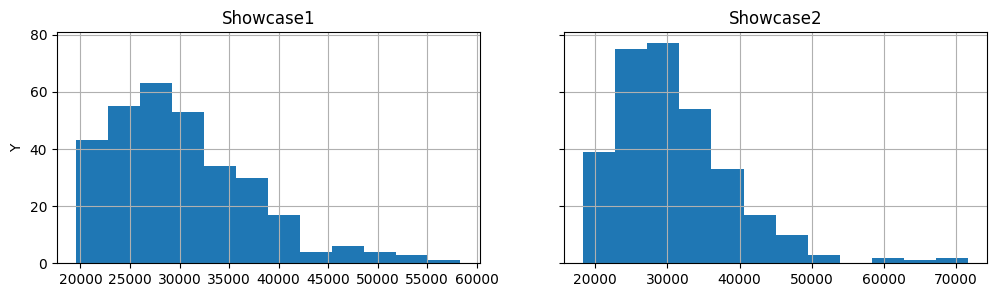

In [4]:
y_data = [
    Showcase1,
    Showcase2
]

titles = ["Showcase1", "Showcase2"]

fig, axes = plt.subplots(
    nrows=1,
    ncols = len(y_data),
    figsize = (12,3),
    sharey=True
)

for ax, y, title in zip(axes, y_data, titles):

    ax.hist(y, bins=12)
    ax.set_title(title)
    ax.grid(True)

axes[0].set_ylabel("Y")
plt.tight_layout

事前分布

$ P(H) $

ショーケース１の価格はどの辺に現れやすいか。

27847, 27560


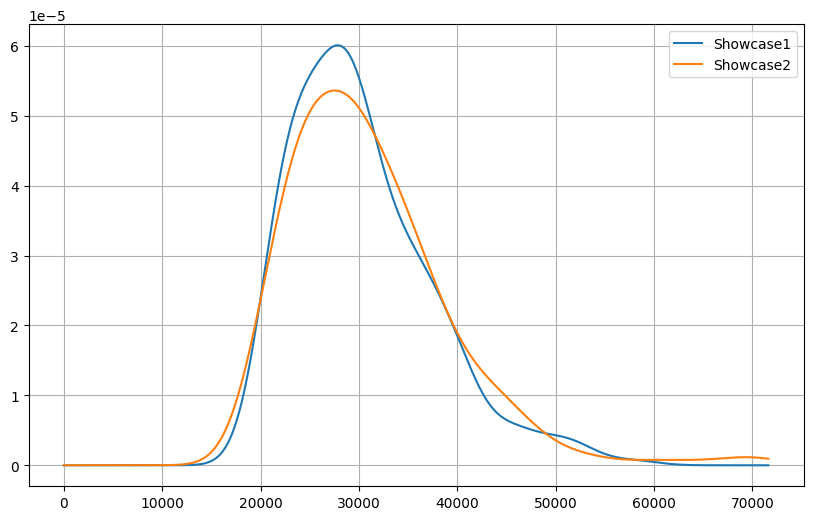

In [5]:
kde1 = gaussian_kde(Showcase1)
kde2 = gaussian_kde(Showcase2)

xmin = min(min(Showcase1), min(Showcase2))
xmax = max(max(Showcase1), max(Showcase2))

x = np.linspace(0,xmax,500)

pdf1 = kde1(x)
pdf2 = kde2(x)

mode_price = x[np.argmax(pdf1)]
mode_price2 = x[np.argmax(pdf2)]
print(f'{mode_price:.0f}, {mode_price2:.0f}')


plt.figure(figsize=(10,6))
plt.plot(x, pdf1, label="Showcase1")
plt.plot(x, pdf2, label='Showcase2')
plt.grid(True)
plt.legend()


In [6]:
price_data3['e'] = price_data3['Showcase1'] - price_data3['Bid1'] - price_data3['Diff1']
price_data3['e'].sum()

0.0

### 6.3 確率密度関数

KDEは各データ点の上に小さなベルカーブ（正規分布）を乗せる

そして、全部足し合わせる


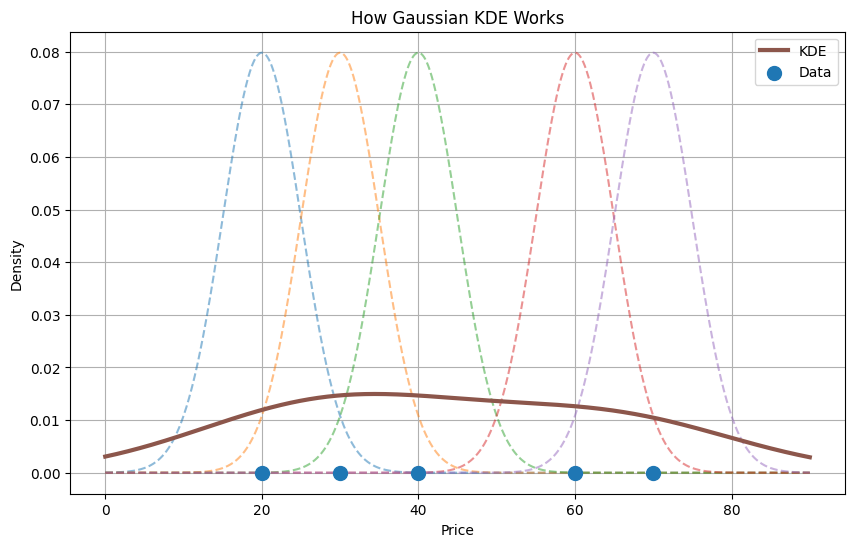

In [7]:
from scipy.stats import norm

data = np.array([20,30,40,60,70])

x = np.linspace(0,90,1000)

# バンド幅
bw = 5

plt.figure(figsize=(10,6))

# 各データ点のガウスカーネル
for d in data:
    y = norm.pdf(x, loc=d, scale=bw)
    plt.plot(x,y,'--',alpha=0.5)

# KDE
kde = gaussian_kde(data)

plt.plot(x, kde(x), linewidth=3, label='KDE')

# 元データの位置
plt.scatter(data, np.zeros_like(data), s=100, zorder=5, label='Data')

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("How Gaussian KDE Works")
plt.legend()
plt.grid(True)

### 6.4 PDFを表現する


In [8]:
import thinkbayes
import scipy 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

class Pdf(object):
    """Represents a probability density function (PDF)"""

    def Density(self, x):
        """Evaluates this Pdf at x,
        Returns: float probability density"""

        raise thinkbayes.UnimplementedMethodException()

    def MakePmf(self, xs, name=''):
        """Makes a discrete version of this Pdf, evaluated at xs.
        xs: equally-spaced sequence of values
        Returns: new Pmf"""

        pmf = thinkbayes.Pmf(name=name)
        for x in xs:
            pmf.Set(x, self.Density(x))
        pmf.Normalize()
        return pmf

class GaussianPdf(Pdf):
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def Density(self, x):
        return scipy.stats.norm.pdf(x, self.mu, self.sigma)

class EstimatedPdf(Pdf):
    def __init__(self, sample):
        self.kde = scipy.stats.gaussian_kde(sample)

    def Density(self,x):
        return self.kde.evaluate(x)


def MakeHistFromList(t, name=""):
    """Makes a histogram from an unsorted sequence of values.
    Args:
        t: sequence of numbers
        name: string name for this histogram
    Returns:
        Hist object"""

    hist = thinkbayes.Hist(name=name)
    [hist.Incr(x) for x in t]
    return hist

def MakeCdfFromList(seq, name=""):
    """Creates a CDF from an unsorted sequence.
    Args:
        seq: unsorted sequence of sortable vales
        name: string name for the cdf
    Returns:
        Cdf object"""

    hist = MakeHistFromList(seq)
    return MakeCdfFromList(hist, name)

def ReadData(filename="showcases.2011.csv"):
    """Reads a CSV file of data.
    Args:
    filename: string filenama

    Returns: sequence of (price1 price2 bid1 bid2 diff1 diff2) tuples
    """

    fp = open(filename)
    reader = csv.reader(fp)
    res = []

    for t in reader:
        _heading = t[0]
        data = t[1:]
        try:
            data = [int(x) for x in data]
            # print(heading, data[0], len(data))
            res.append(data)
        except ValueError:
            pass
    fp.close()
    return list(zip(*res))


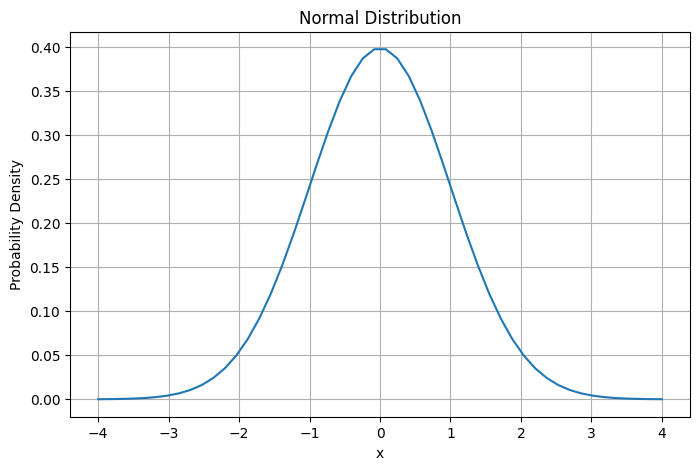

In [9]:
# パラメータ
mu = 0
sigma = 1

# xの範囲
x = np.linspace(mu - 4*sigma, mu + 4*sigma)

pdf = GaussianPdf(mu, sigma)
y = pdf.Density(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label=f"mu={mu}, sigma={sigma}")
plt.title("Normal Distribution")
plt.ylabel("Probability Density")
plt.xlabel("x")
plt.grid(True)


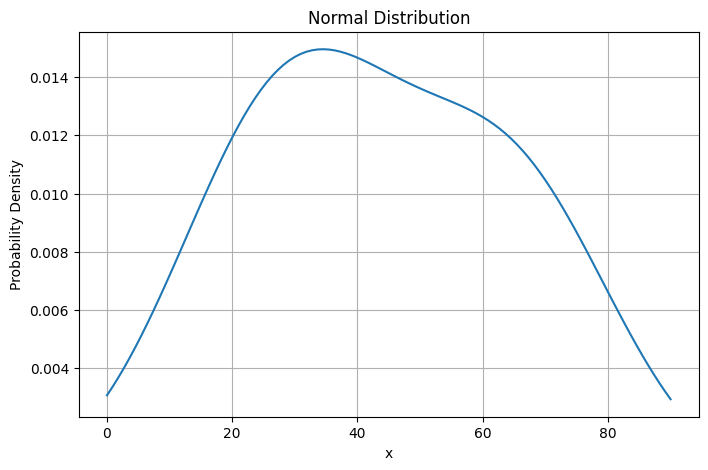

In [10]:
data = np.array([20, 30, 40, 60, 70])
x = np.linspace(0,90,100)

pdf = EstimatedPdf(sample=data)
y = pdf.Density(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label=f"mu={mu}, sigma={sigma}")
plt.title("Normal Distribution")
plt.ylabel("Probability Density")
plt.xlabel("x")
plt.grid(True)

In [11]:
len(Showcase1)

313

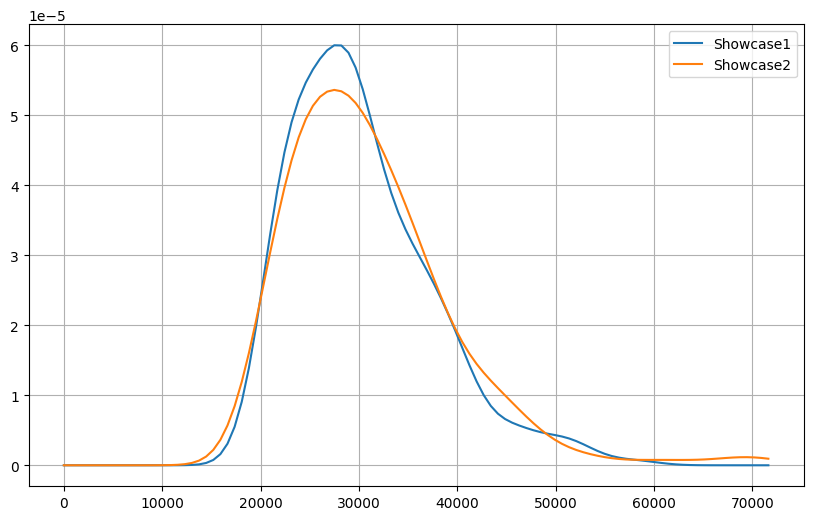

In [12]:
xmin = min(min(Showcase1), min(Showcase2))
xmax = max(max(Showcase1), max(Showcase2))

x = np.linspace(0,xmax,100)

pdf1 = EstimatedPdf(Showcase1)
pdf2 = EstimatedPdf(Showcase2)

y1 = pdf1.Density(x)
y2 = pdf2.Density(x)
y3 = pdf1.MakePmf(x)
y4 = pdf2.MakePmf(x)


plt.figure(figsize=(10,6))
plt.plot(x, y1, label="Showcase1")
plt.plot(x, y2, label='Showcase2')
plt.grid(True)
plt.legend()



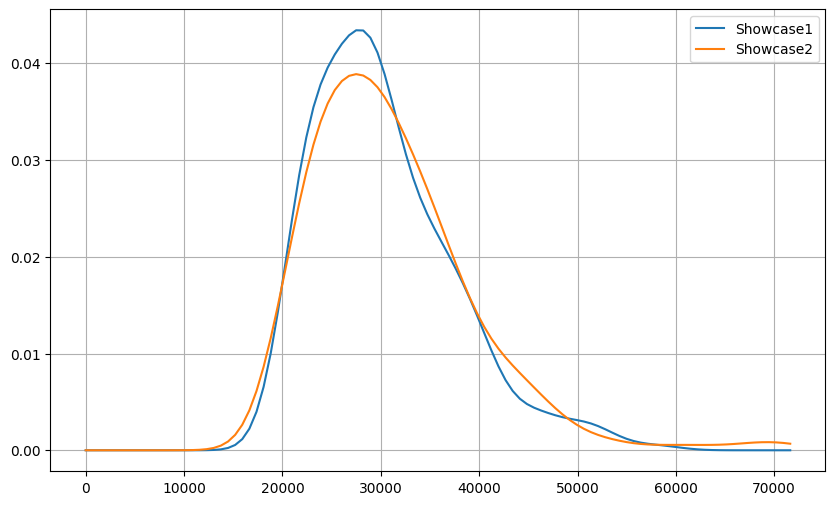

In [13]:
def pmf_to_xy(pmf):
    xs, ps = map(np.array, zip(*pmf))
    return xs, ps

xs1, ps1 = pmf_to_xy(y3.Items())
xs2, ps2 = pmf_to_xy(y4.Items())

plt.figure(figsize=(10,6))

plt.plot(xs1, ps1, label="Showcase1")
plt.plot(xs2, ps2, label="Showcase2")
plt.grid(True)
plt.legend()

Text(0.5, 1.0, 'EstimatedPdf')

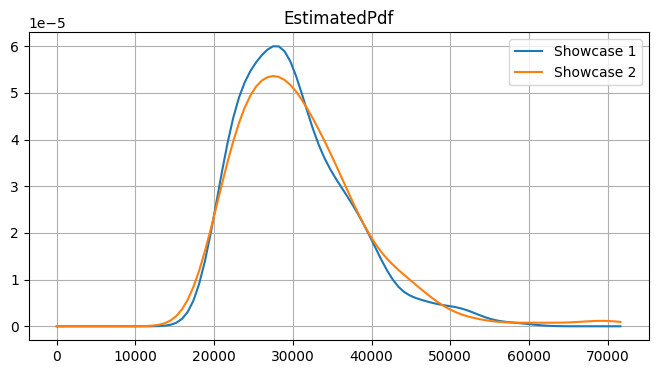

In [14]:
data = ReadData(filename="showcases.2011.csv")
data += ReadData(filename="showcases.2012.csv")

cols = zip(*data)
price1, price2, bid1, bid2, diff1, diff2 = cols

pdf1 = EstimatedPdf(price1)
pdf2 = EstimatedPdf(price2)

xmax = max(max(price1),max(price2))
x = np.linspace(0,xmax,100)

y1 = pdf1.Density(x)
y2 = pdf2.Density(x)

plt.figure(figsize=(8, 4))
plt.plot(x,y1, label="Showcase 1")
plt.plot(x,y2, label="Showcase 2")
plt.legend()
plt.grid(True)
plt.title("EstimatedPdf")


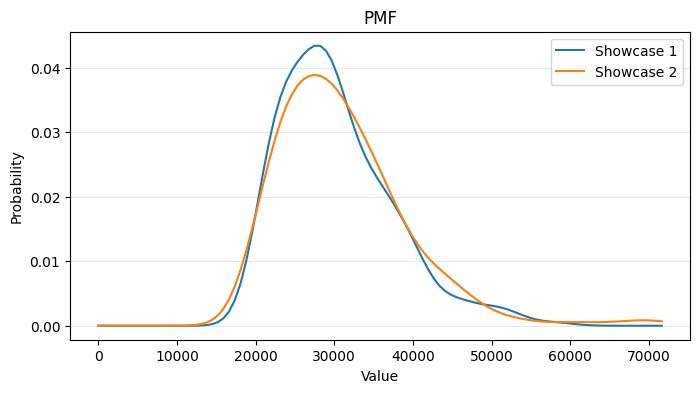

In [15]:
pmf1 = pdf1.MakePmf(x)
pmf2 = pdf2.MakePmf(x)

xs1, ps1 = zip(*pmf1.Items())
xs2, ps2 = zip(*pmf2.Items())

plt.figure(figsize=(8, 4))
plt.plot(xs1, ps1, label="Showcase 1")
plt.plot(xs2, ps2, label="Showcase 2")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.title("PMF")
plt.grid(axis="y", alpha=0.3)
plt.legend()


### 6.5 出場者をモデル化する


人間は商品の値段をどのぐらい正確に当てられるかを確率分布として作る。

実際の値段が price だとして、出場者の推測が guess である尤度は？

価格が５万円だったと仮定したとき、４万７千円と答える人はどのぐらいいるか。

$ p(guess|price) $

どうやって求めるのか。

過去のデータから、

$ error = guess - price $

＝＞　人間はこのぐらい外すという分布ができる。

＝＞　人間の推測ミス

＝＞　出場者の推測の乖離度が error 以内になる確からしさはどのぐらいか？。


誤差分布

$ P(error) $ 

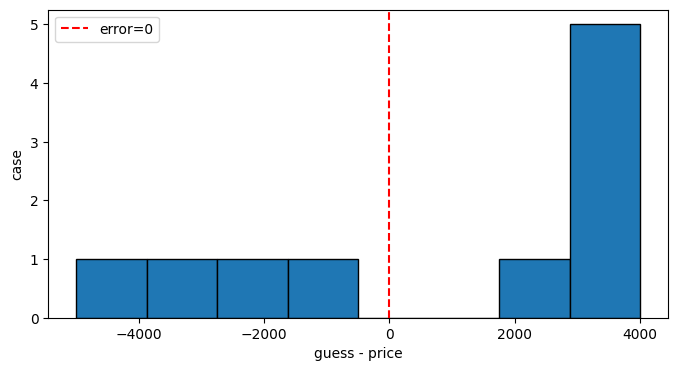

In [16]:
past_price = np.array([50000, 42000, 60000, 80000, 30000, 55000, 47000, 68000, 72000, 51000])
past_guess = np.array([47000, 43000, 57000, 76000, 35000, 52000, 49000, 64000, 70000, 54000])

past_errors = past_price - past_guess

plt.figure(figsize=(8,4))
plt.hist(past_errors,bins=8, edgecolor='black')
plt.axvline(0, color="red", linestyle='--', label="error=0")

plt.xlabel("guess - price")
plt.ylabel("case")
plt.title("")
plt.legend()

In [17]:
df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


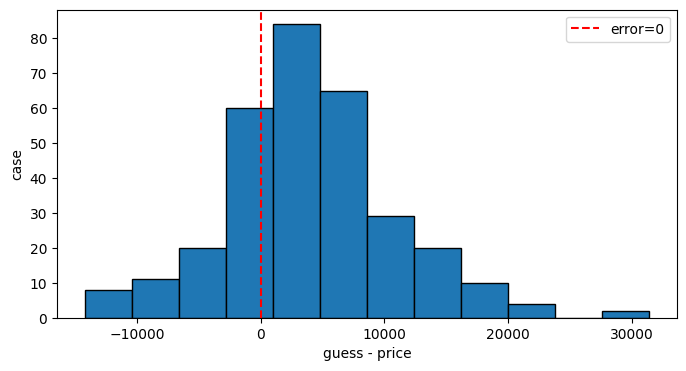

In [18]:
past_price = df3['Showcase 1'].to_numpy()
past_guess = df3['Bid 1'].to_numpy()

past_errors = past_price - past_guess

plt.figure(figsize=(8,4))
plt.hist(past_errors,bins=12, edgecolor='black')
plt.axvline(0, color="red", linestyle='--', label="error=0")

plt.xlabel("guess - price")
plt.ylabel("case")
plt.title("")
plt.legend()

In [19]:
# 今回の出場者

observed_guess = 47000
candidate_price = 50000
candidate_error =  candidate_price - observed_guess
bin_width = 1000

bins = np.arange(
    past_errors.min() - bin_width,
    past_errors.max() + 2 * bin_width,
    bin_width
)

counts, edges = np.histogram(past_errors, bins=bins)

index = np.digitize(candidate_error, edges) -1

if 0 <= index < len(counts):
    likelihood = counts[index] / len(past_errors)
else:
    likelihood = 0

In [20]:
print(f"observed_guess : {observed_guess}")
print(f"candidate_price: {candidate_price}")
print(f"candidate_error: {candidate_error}")
print(f"Likelihood : {likelihood:.3f}")

observed_guess : 47000
candidate_price: 50000
candidate_error: 3000
Likelihood : 0.061


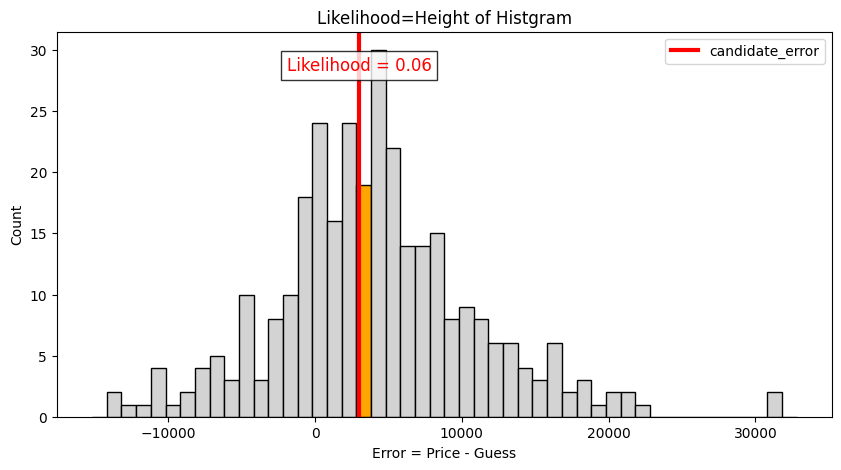

In [21]:
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.hist(
    past_errors,
    bins=bins,
    edgecolor = "black",
    color="lightgray"
)

patches = bars[2]

if 0<=index<len(patches):
    patches[index].set_facecolor("orange")

ax.axvline(
    candidate_error,
    color="red",
    linewidth=3,
    label="candidate_error"
)

ymax = ax.get_ylim()[1]

ax.text(
    candidate_error,
    ymax*0.9,
    f"Likelihood = {likelihood:.2f}",
    color="red",
    ha="center",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.set_title("Likelihood=Height of Histgram")
ax.set_xlabel("Error = Price - Guess")
ax.set_ylabel("Count")
ax.legend()

### 6.5 

$ diff = price - bid $

In [22]:
diff1 = df3["Difference 1"].to_numpy()

In [23]:
df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


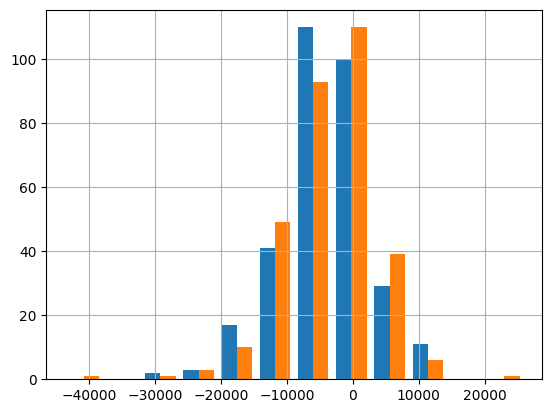

In [24]:
# errorを作る

error1 = price_data3["Bid1"] - price_data3["Showcase1"]
error2 = price_data3["Bid2"] - price_data3["Showcase2"]

x_min = min(min(error1), min(error2))
x_max = max(max(error1), max(error2))

x = np.linspace(x_min,x_max,1000)

# ヒストグラムを見る

y_data = [
    error1,
    error2
]

titles = ["error1", "error2"]

plt.hist(y_data, bins=12)
plt.grid(True)






error1 mean: -4116
error1 std: 6900
error2 mean: -3676
error2 std: 6886


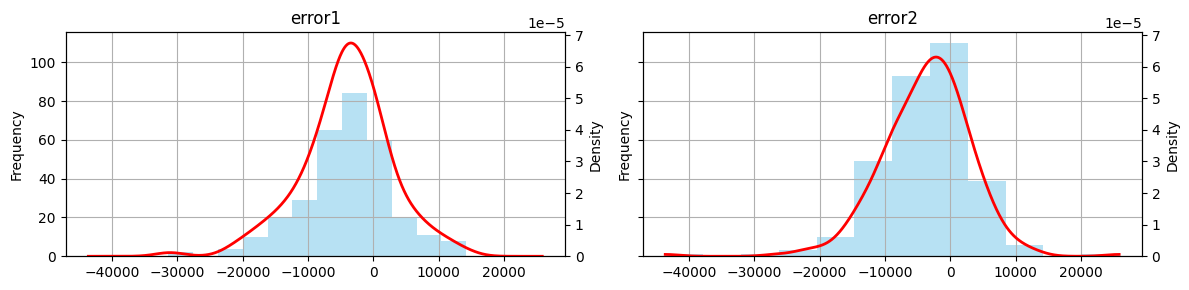

In [25]:
fig, axes = plt.subplots(
    nrows=1,
    ncols = len(y_data),
    figsize = (12,3),
    sharey=True
)

# y_dataが一つだけの場合への対策
if len(y_data) == 1:
    axes = [axes]

titles = ["error1", "error2"]
x = np.linspace(x_min,x_max,1000)

kmax = max(gaussian_kde(y)(x).max() for y in y_data)

for ax1, y, title in zip(axes, y_data, titles):

    kde = gaussian_kde(y)


    ax1.hist(y, bins=12, alpha=0.6, color="skyblue")
    ax1.set_ylabel("Frequency")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(x,kde(x), color="red", linewidth=2)
    ax2.set_ylabel("Density")

    ax2.set_ylim(0, kmax*1.05)

    ax1.set_title(title)
    

    print(f'{title} mean: {y.mean():.0f}')
    print(f'{title} std: {y.std():.0f}')

plt.tight_layout()

In [26]:
error2.mean()

-3675.891373801917

In [27]:
diff1 = df3["Difference 1"].to_numpy()
diff2 = df3["Difference 2"].to_numpy()

import numpy as np
import matplotlib.pyplot as plt

# データを順に並べる
x1 = np.sort(diff1)
x2 = np.sort(diff2)

# 累積確率
cdf1 = np.arange(1, len(x1)+1) / len(x1)
cdf2 = np.arange(1, len(x2)+1) / len(x2)

# Difference1
n1 = np.searchsorted(x1, 0, side="right")
cdf1_at0 = n1/len(x1)

# Difference2
n2 = np.searchsorted(x2, 0, side="right")
cdf2_at0 = n2/len(x2)



CDF1(0) = 0.246
CDF2(0) = 0.291


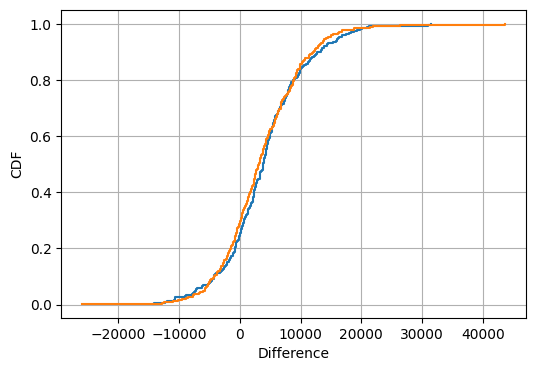

In [28]:
# グラフ
plt.figure(figsize=(6,4))
plt.step(x1, cdf1, where="post")
plt.step(x2, cdf2, where="post")
plt.xlabel("Difference")
plt.ylabel("CDF")
plt.grid(True)

print(f"CDF1(0) = {cdf1_at0:.3f}")
print(f"CDF2(0) = {cdf2_at0:.3f}")

In [29]:
df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


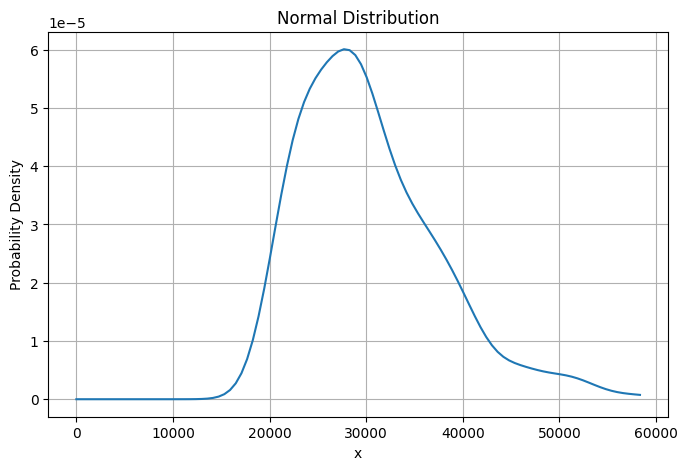

In [30]:
data = df3["Showcase 1"].to_numpy()
x = np.linspace(0,max(data),100)

pdf = EstimatedPdf(sample=data)
y = pdf.Density(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label=f"mu={mu}, sigma={sigma}")
plt.title("Normal Distribution")
plt.ylabel("Probability Density")
plt.xlabel("x")
plt.grid(True)

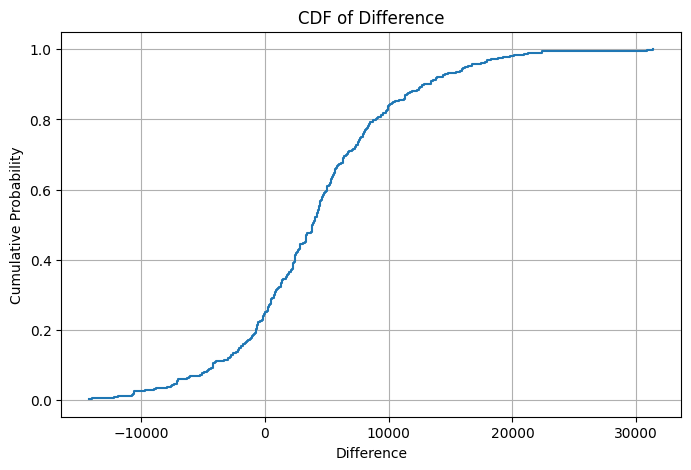

In [31]:
diffs = df3["Difference 1"].to_numpy()

cdf_diff = thinkbayes.MakeCdfFromList(diffs)

xs, ps = zip(*cdf_diff.Items())

plt.figure(figsize=(8, 5))

plt.step(xs, ps, where="post")

plt.xlabel("Difference")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Difference")

plt.grid(True)
plt.show()





### 6.6 尤度

尤度関数を書く

thinkbayes.Suite を拡張して新しいクラスを定義する

In [32]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """

        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensityGauss(error)

        return like


In [33]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0,75000,n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (gegative means over)"""

        self.pdf_price = EstimatedPdf(prices)
        self.pdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error_gauss = thinkbayes.GaussianPdf(mu, sigma)
        
        self.pdf_error_kde = EstimatedPdf(diffs)
        
    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """"Makes a posterior distribution based on estimated price.
        Sets attributes prior and posterior.T
        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)

    def PmfPrice(self):
        """Returns a new Pmf of prices.
        A discrete version of the estimated Pdf.Density"""

        return self.pdf_price.MakePmf(self.price_xs)


In [34]:
prices1 = df3["Showcase 1"].to_numpy()
bids1 = df3["Bid 1"].to_numpy()
diffs1 = df3["Difference 1"].to_numpy()


In [35]:
player1 = Player(prices1, bids1, diffs1)
player1.ErrorDensityGauss(0)


5.791106126414929e-05

In [36]:
prior_y = []

In [37]:
guess = 20000

if not hasattr(player1, "posterior"):
    player1.MakeBeliefs(guess)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

guess = 20000

# 誤差データ
diffs = np.asarray(diffs1).ravel()

# 誤差分布 KDE
error_kde = gaussian_kde(diffs)

# 価格軸
prices = np.linspace(0, 75000, 101)

# 尤度
likelihood = []

for price in prices:
    error = float(price - guess)
    likelihood.append(error_kde(error))

likelihood = np.array(likelihood).ravel()

# 正規化
#likelihood = likelihood / np.trapz(likelihood, prices)
likelihood = likelihood / likelihood.sum()




[1.] [1.]


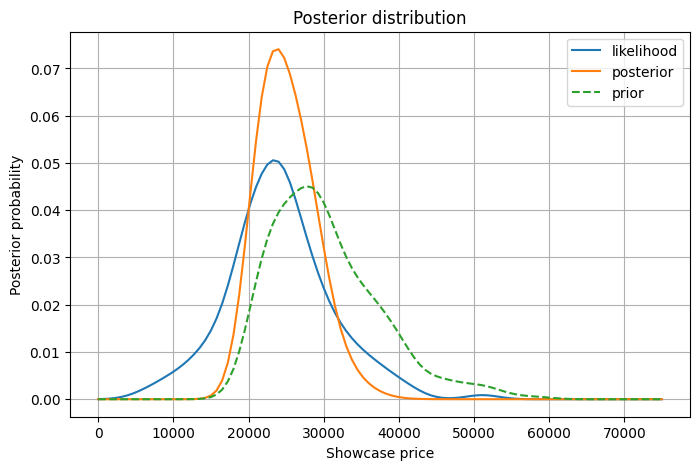

In [39]:
player1.MakeBeliefs(guess=guess)

xs, ps = zip(*player1.posterior.Items())
xs1, ps1 = zip(*player1.prior.Items())

print(sum(ps), sum(ps1))


plt.figure(figsize=(8,5))

plt.plot(prices, likelihood, label="likelihood")

plt.plot(xs, ps, label="posterior")
plt.plot(xs1, ps1, label="prior", linestyle="--")
plt.xlabel("Showcase price")
plt.ylabel("Posterior probability")
plt.title("Posterior distribution")
plt.grid(True)
plt.legend()

### 6.7 更新

Player: 出場者の推測値を取って、事後確率を計算するメソッドを提供する。




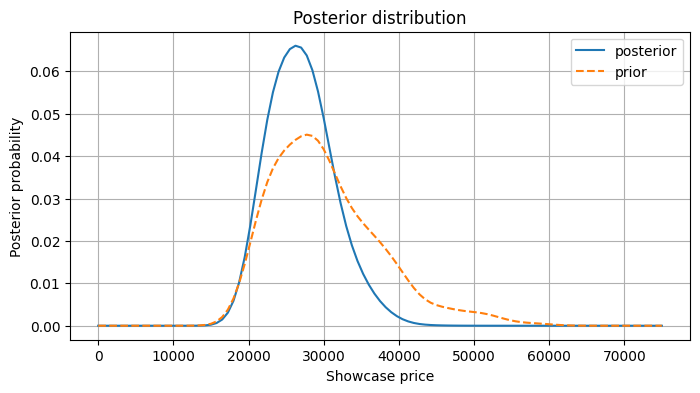

In [40]:
player1.MakeBeliefs(guess=25000)

xs, ps = zip(*player1.posterior.Items())
xs1, ps1 = zip(*player1.prior.Items())

plt.figure(figsize=(8,4))
plt.plot(xs, ps, label="posterior")
plt.plot(xs1, ps1, label="prior", linestyle="--")
plt.xlabel("Showcase price")
plt.ylabel("Posterior probability")
plt.title("Posterior distribution")
plt.grid(True)
plt.legend()

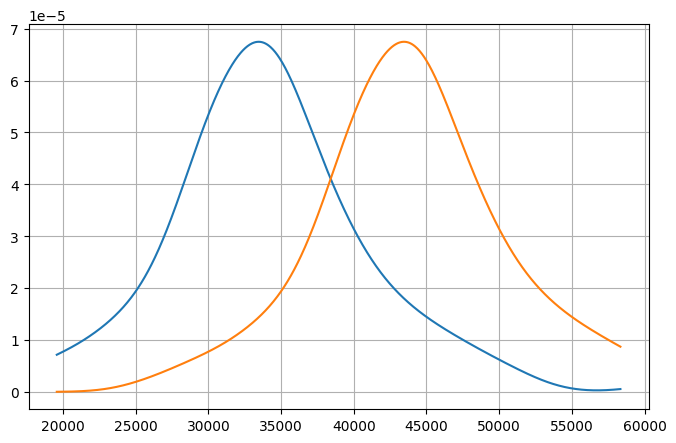

In [41]:
# 予測額 (guess) を決める

guesses = [30000,40000]
plt.figure(figsize=(8,5))

# 価格候補を並べる
for guess in guesses:

    kde_error = gaussian_kde(error1)

    prices1 = price_data3['Showcase1']

    prices = np.linspace(prices1.min(), prices1.max(),1000)

    errors = guess - prices
    likelihood = kde_error(errors)

    plt.plot(prices, likelihood)

plt.grid(True)



$ P(D|H) $

In [42]:
guess = 30000

xs = np.linspace(0,75000,1000)

error = guess - xs

likelihood = kde_error(error)

likelihood_scaled = likelihood / likelihood.sum()



In [43]:
prior = kde1(xs)
prior = prior / prior.sum()

posterior = prior * likelihood
posterior /= posterior.sum()

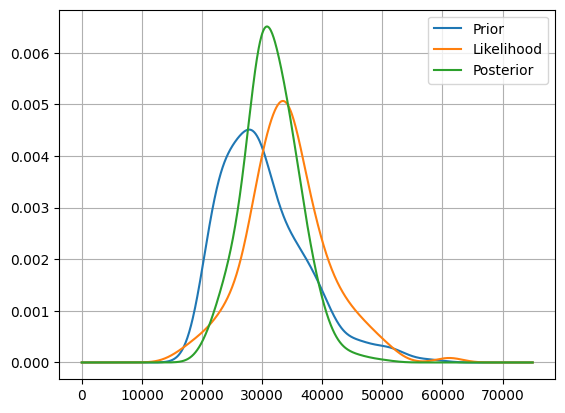

In [44]:
plt.plot(xs, prior, label="Prior")
plt.plot(xs, likelihood_scaled, label="Likelihood")
plt.plot(xs, posterior, label="Posterior")
plt.legend()
plt.grid(True)

In [45]:
print(prior.max())
print(likelihood.max())
print(posterior.max())

0.004511475513015472
6.747731178578113e-05
0.006508934876287827


In [46]:


# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(prices)
kde_error = gaussian_kde(error)


prior = kde_price(xs)

likelihood = kde_error(guess - xs)

unnormalized = prior * likelihood

posterior = unnormalized / unnormalized.sum()

print("prior max       :", prior.max())
print("likelihood max  :", likelihood.max())
print("unnormalized max:", unnormalized.max())
print("posterior max   :", posterior.max())
print("posterior sum   :", posterior.sum())

prior max       : 2.5761365687472704e-05
likelihood max  : 1.3319999999926665e-05
unnormalized max: 3.431413909523254e-10
posterior max   : 0.0019343980387273021
posterior sum   : 1.0


prior sum      = 1.0000000000000002
likelihood sum = 0.9999999999999997
posterior sum  = 1.0


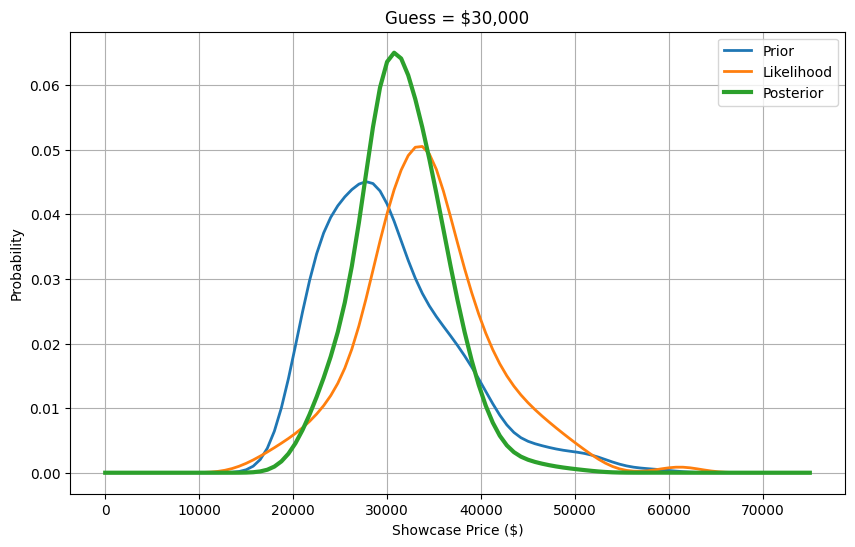

In [47]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------
# 1. データ
# -----------------------------------

showcase = price_data3["Showcase1"].dropna().values
bid       = price_data3["Bid1"].dropna().values

error = bid - showcase

# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(showcase)
kde_error = gaussian_kde(error)

# -----------------------------------
# 3. 観測データ
# -----------------------------------

guess = 30000

# 仮説空間
xs = np.linspace(0, 75000, 101)

# -----------------------------------
# 4. Prior
# -----------------------------------

prior = kde_price(xs)

# 離散確率化
prior = prior / prior.sum()

# -----------------------------------
# 5. Likelihood
# -----------------------------------

errors = guess - xs

likelihood = kde_error(errors)

# 比較しやすいように正規化
likelihood = likelihood / likelihood.sum()

# -----------------------------------
# 6. Posterior
# -----------------------------------

posterior = prior * likelihood

posterior = posterior / posterior.sum()

# -----------------------------------
# 7. 確認
# -----------------------------------

print("prior sum      =", prior.sum())
print("likelihood sum =", likelihood.sum())
print("posterior sum  =", posterior.sum())

# -----------------------------------
# 8. グラフ
# -----------------------------------

plt.figure(figsize=(10,6))

plt.plot(xs, prior,
         label="Prior",
         linewidth=2)

plt.plot(xs, likelihood,
         label="Likelihood",
         linewidth=2)

plt.plot(xs, posterior,
         label="Posterior",
         linewidth=3)

plt.xlabel("Showcase Price ($)")
plt.ylabel("Probability")

plt.title(f"Guess = ${guess:,.0f}")

plt.legend()
plt.grid()

plt.show()

In [48]:
import inspect
print(inspect.getsource(thinkbayes.MakeCdfFromList))

def MakeCdfFromList(seq, name=''):
    """Creates a CDF from an unsorted sequence.

    Args:
        seq: unsorted sequence of sortable values
        name: string name for the cdf

    Returns:
       Cdf object
    """
    hist = MakeHistFromList(seq)
    return MakeCdfFromHist(hist, name)



### 6.8 最前な推定

事後推定分布を使って、期待値を最大化できる推測値を計算する。



In [49]:
class GainCalculator(object):
    """Calculates computation of expected gain"""

    def __init__(self, player, opponent):
        """Constructs the calculator.
        player: Player
        opponent: Player
        """
        self.player = player
        self.opponent = opponent

    def ExpectedGains(self, low=0, high=75000, n=101):
        """Comutes expected gains for a range of bits.
        
        los: low bid
        high: high bid
        n: number of bids to evaluates
        
        returns: tuple (sequence of bids, sequence of gains)
        """

        bids = np.linspace(low, high, n)
        gains = [self.ExpectedGain(bid) for bid in bids]

        return bids, gains

    def ExpectedGain(self, bid):
        """Computes the expected return of a given bid.
        bid: your bid"""

        suite = self.player.posterior
        total = 0
        for price, porob in sorted(suite.Irems()):
            gain = self.Gain(bid, price)
            total += prob * gain
        return total

class GainCalculator(object):
    """Encapsulates computation of expected gain"""

    def __init__(self, player, opponent):
        """Constructs the calculator.
        
        player: player
        opponent: opponent
        """
        self.player = player
        self.opponent = opponent

    def ExpectedGains(self, low=0, high=75000, n=101):
        """Computes expected gains ffor a range of bids.
        
        low: low bid
        hight: high bid
        n: number of bids to evaluate

        returns: tuple (sequence of bids, sequence of gains)
        """

        bids = np.linspace(low, high, n)
        gains = [self.ExpectedGain(bid) for bid in bids]

        return bids, gains
    
    def ExpectedGain(self, bid):
        """Computes the expected return of a given bid.
        
        bid: your bid
        """

        suite = self.player.posterior
        total = 0
        for price, prob in sorted(suite.Items()):
            gain = self.Gain(bid, price)
            total += prob*gain
        return total

    def Gain(self, bid, price):
        """Computes the return of a bid, given the actual price.
        bid: number
        price: actual price
        """
        # if you overbid, you get nothing
        if bid > price:
            return 0

        # otherwise compute the probability of winning
        diff = price - bid
        prob = self.ProbWin(diff)

        # if you are within 250 dollers, you win both showcases
        if diff <= 250:
            return 2*price*prob
        else:
            return price*prob

    def ProbWin(self, diff):
        """Computes the probability of winning for a given diff.
        diff: how much your bid was off by
        """

        prob = (self.opponent.ProbOverbid() +
                self.opponent.ProbWorseThan(diff))
        return prob






    


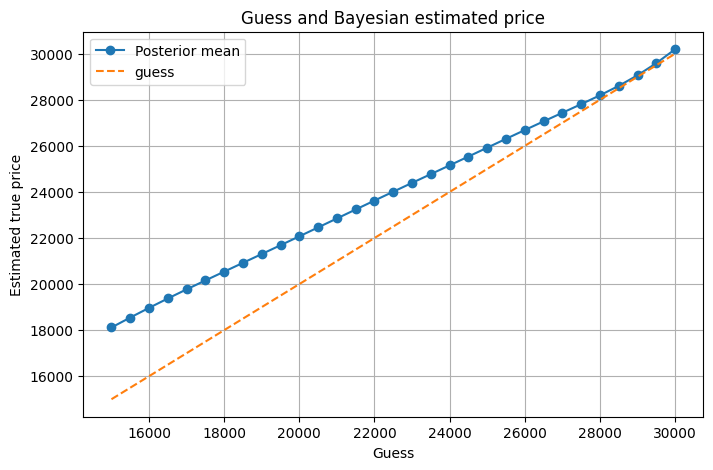

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# ===================================
# 仮のデータ
# （ここをあなたのデータに置き換える）
# ===================================

np.random.seed(1)

# 真の価格データ（Prior）
price_data = np.random.normal(
    22000, 
    3000, 
    1000
)

# 出場者の誤差データ
# error = true price - guess
error_data = np.random.normal(
    2000,
    1500,
    1000
)


# ===================================
# KDE
# ===================================

price_kde = gaussian_kde(price_data)
error_kde = gaussian_kde(error_data)


# ===================================
# 価格軸
# ===================================

prices = np.linspace(
    10000,
    35000,
    500
)


# Prior
prior = price_kde(prices)

# 正規化
prior = prior / np.trapz(prior, prices)



# ===================================
# guessを変えてPosteriorを見る
# ===================================

guesses = np.arange(
    15000,
    30001,
    500
)


posterior_mean = []


for guess in guesses:

    # Likelihood
    likelihood = error_kde(prices - guess)


    # Bayes更新
    posterior = prior * likelihood


    # 正規化
    posterior = posterior / np.trapz(
        posterior,
        prices
    )


    # 期待値
    mean = np.trapz(
        prices * posterior,
        prices
    )

    posterior_mean.append(mean)



# ===================================
# グラフ
# ===================================

plt.figure(figsize=(8,5))

plt.plot(
    guesses,
    posterior_mean,
    marker="o",
    label="Posterior mean"
)


plt.plot(
    guesses,
    guesses,
    "--",
    label="guess"
)


plt.xlabel("Guess")
plt.ylabel("Estimated true price")

plt.title(
    "Guess and Bayesian estimated price"
)

plt.grid()
plt.legend()

plt.show()

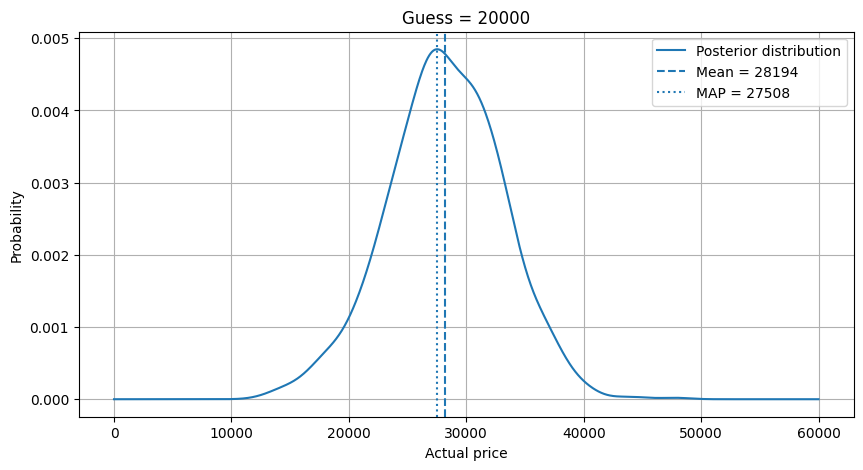

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ======================================
# 過去データから得た「誤差分布」を作る
# error = actual_price - guess
# ======================================

# 仮の過去データ
# 実際には ThinkBayes の data から作る部分です
np.random.seed(1)

errors = np.random.normal(
    loc=8000,     # 平均誤差 +8000ドル
    scale=5000,   # ばらつき
    size=1000
)

# KDEで誤差分布を滑らかにする
kde = gaussian_kde(errors)


# ======================================
# Guessを変化させて事後分布を見る
# ======================================

guess = 20000   # ←ここを変える

# 実際価格の候補
price = np.linspace(0, 60000, 1000)


# 実際価格 - guess が誤差になる
likelihood = kde(price - guess)


# 正規化（確率分布にする）
posterior = likelihood / np.sum(likelihood)


# 平均（期待値）
mean_price = np.sum(price * posterior)


# 最頻値
map_price = price[np.argmax(posterior)]


# ======================================
# グラフ
# ======================================

plt.figure(figsize=(10,5))

plt.plot(
    price,
    posterior,
    label="Posterior distribution"
)

plt.axvline(
    mean_price,
    linestyle="--",
    label=f"Mean = {mean_price:.0f}"
)

plt.axvline(
    map_price,
    linestyle=":",
    label=f"MAP = {map_price:.0f}"
)


plt.title(
    f"Guess = {guess}"
)

plt.xlabel("Actual price")
plt.ylabel("Probability")

plt.legend()
plt.grid()

plt.show()

Guess = 20000
Mean = 28207.0
MAP = 27000


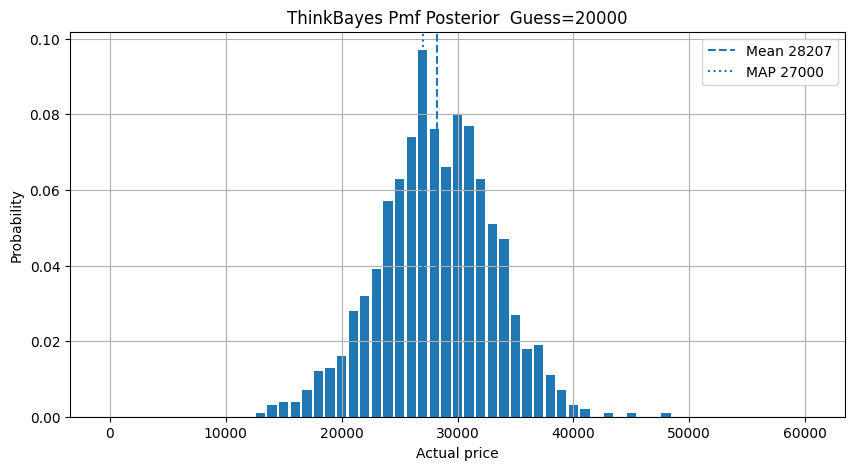

In [52]:
import numpy as np
import matplotlib.pyplot as plt

from thinkbayes import Pmf


# ----------------------------
# 誤差データを作る
# error = actual - guess
# ----------------------------

np.random.seed(1)

errors = np.random.normal(
    loc=8000,
    scale=5000,
    size=1000
)


# 1000ドル単位に丸める
errors = np.round(errors / 1000) * 1000


# 誤差のPmf
error_pmf = Pmf()

for error in errors:
    error_pmf.Incr(error)

error_pmf.Normalize()



# ----------------------------
# 最初のGuess
# ----------------------------

guess = 20000



# ----------------------------
# 実際価格の候補
# ----------------------------

prices = range(0, 60001, 1000)



# ----------------------------
# Posterior Pmf
# ----------------------------

posterior = Pmf()


for price in prices:

    error = price - guess

    likelihood = error_pmf.Prob(error)

    posterior.Set(price, likelihood)


posterior.Normalize()



# ----------------------------
# 推定値
# ----------------------------

mean = posterior.Mean()


map_price = max(
    posterior.Items(),
    key=lambda x: x[1]
)[0]


print("Guess =", guess)
print("Mean =", mean)
print("MAP =", map_price)



# ----------------------------
# グラフ
# ----------------------------

items = list(posterior.Items())

x = [item[0] for item in items]
y = [item[1] for item in items]


plt.figure(figsize=(10,5))

plt.bar(
    x,
    y,
    width=800
)


plt.axvline(
    mean,
    linestyle="--",
    label=f"Mean {mean:.0f}"
)

plt.axvline(
    map_price,
    linestyle=":",
    label=f"MAP {map_price}"
)


plt.xlabel("Actual price")
plt.ylabel("Probability")

plt.title(
    f"ThinkBayes Pmf Posterior  Guess={guess}"
)

plt.legend()
plt.grid()

plt.show()

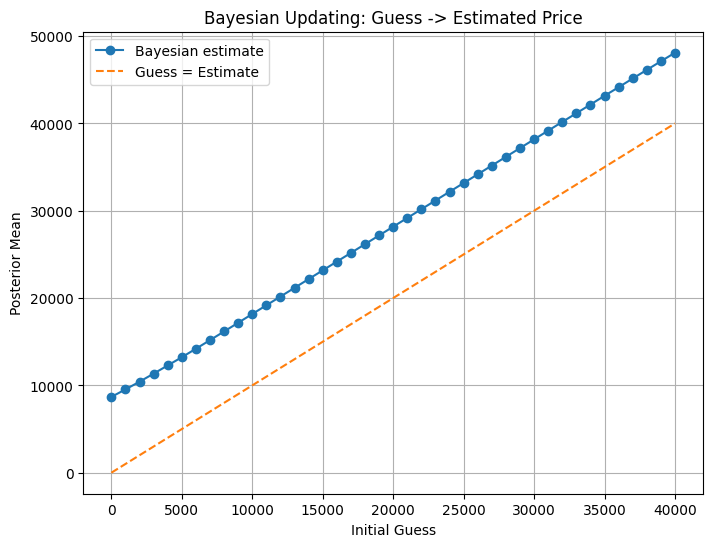

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from thinkbayes import Pmf


# ==================================
# 過去データから誤差分布を作る
# error = actual - guess
# ==================================

np.random.seed(1)

errors = np.random.normal(
    loc=8000,
    scale=5000,
    size=2000
)

errors = np.round(errors / 1000) * 1000


error_pmf = Pmf()

for e in errors:
    error_pmf.Incr(e)

error_pmf.Normalize()



# ==================================
# GuessごとにBayes推定する関数
# ==================================

def bayes_estimate(guess):

    posterior = Pmf()

    for price in range(0, 60001, 1000):

        error = price - guess

        likelihood = error_pmf.Prob(error)

        posterior.Set(price, likelihood)

    posterior.Normalize()

    return posterior.Mean()



# ==================================
# Guessを動かす
# ==================================

guesses = np.arange(0, 40001, 1000)

estimates = []

for guess in guesses:

    estimate = bayes_estimate(guess)

    estimates.append(estimate)



# ==================================
# グラフ
# ==================================

plt.figure(figsize=(8,6))

plt.plot(
    guesses,
    estimates,
    marker="o",
    label="Bayesian estimate"
)

# Guess = 推定値 の線
plt.plot(
    guesses,
    guesses,
    linestyle="--",
    label="Guess = Estimate"
)


plt.xlabel("Initial Guess")
plt.ylabel("Posterior Mean")

plt.title(
    "Bayesian Updating: Guess -> Estimated Price"
)

plt.grid()
plt.legend()

plt.show()

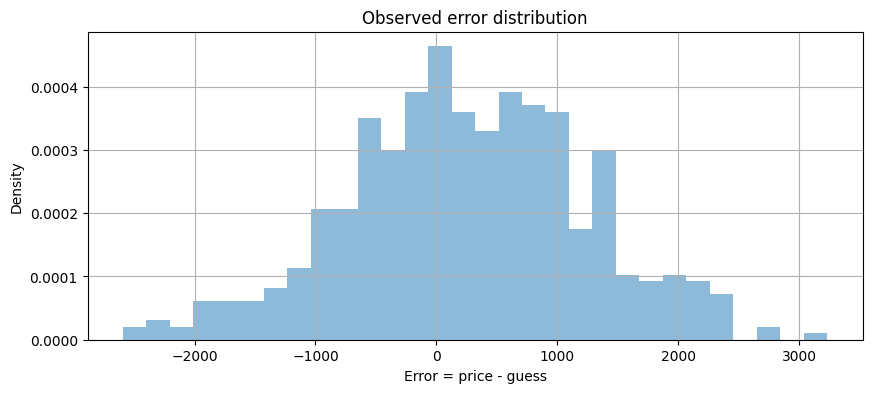

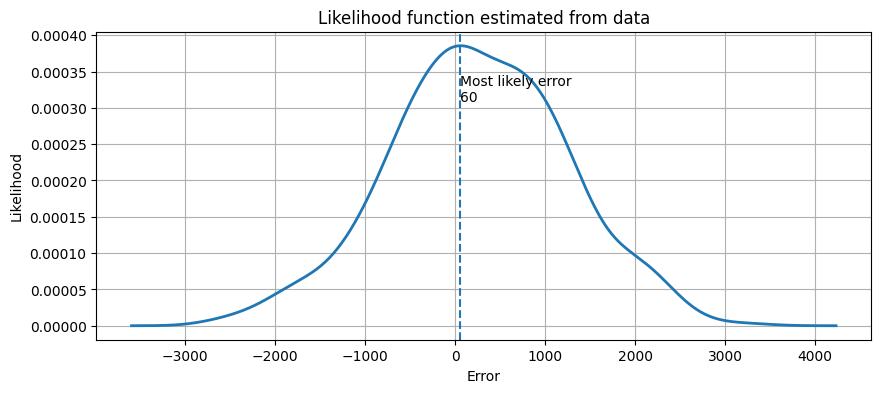

推測価格: 5000
最もありそうな誤差: 60
修正後推定価格: 5060


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------------------
# 例：出場者の誤差データ
# error = 実際価格 - 推測価格
# ThinkBayes Chapter 6.5 の考え方
# ---------------------------------------

np.random.seed(1)

error = np.random.normal(
    loc=200,      # 平均的な外れ方
    scale=1000,   # 誤差のばらつき
    size=500
)


# ---------------------------------------
# 1. 誤差の分布（観測データ）
# ---------------------------------------

plt.figure(figsize=(10,4))

plt.hist(
    error,
    bins=30,
    density=True,
    alpha=0.5
)

plt.xlabel("Error = price - guess")
plt.ylabel("Density")
plt.title("Observed error distribution")

plt.grid()
plt.show()



# ---------------------------------------
# 2. KDEで尤度関数を作る
# ---------------------------------------

kde = gaussian_kde(error)


x = np.linspace(
    error.min()-1000,
    error.max()+1000,
    500
)

likelihood = kde(x)



plt.figure(figsize=(10,4))

plt.plot(
    x,
    likelihood,
    linewidth=2
)

plt.xlabel("Error")
plt.ylabel("Likelihood")
plt.title("Likelihood function estimated from data")



# 最大尤度
best_error = x[np.argmax(likelihood)]


plt.axvline(
    best_error,
    linestyle="--"
)

plt.text(
    best_error,
    max(likelihood)*0.8,
    f"Most likely error\n{best_error:.0f}"
)


plt.grid()
plt.show()



# ---------------------------------------
# 3. 推測価格を修正する
# ---------------------------------------

guess = 5000

estimated_price = guess + best_error


print("推測価格:", guess)
print("最もありそうな誤差:", round(best_error))
print("修正後推定価格:", round(estimated_price))

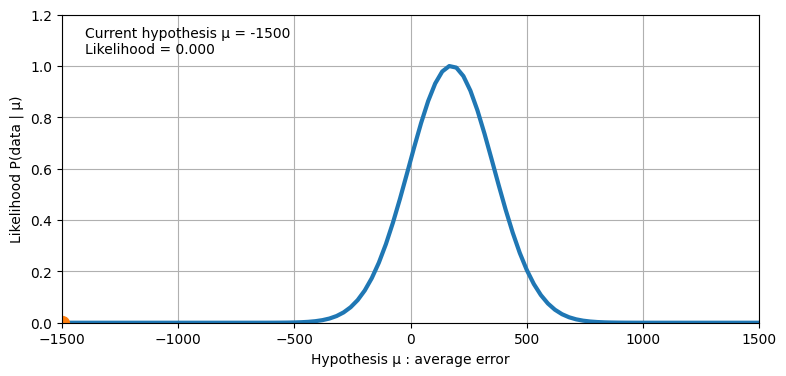

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm

# -----------------------------
# 観測された誤差データ
# price - guess
# -----------------------------
np.random.seed(3)

data = np.random.normal(
    loc=300,
    scale=1000,
    size=30
)


# 仮説 μ（平均誤差）
mus = np.linspace(-1500, 1500, 100)


# -----------------------------
# 尤度計算
# P(data | μ)
# -----------------------------
def likelihood(mu):

    pdf = norm.pdf(
        data,
        loc=mu,
        scale=1000
    )

    # 独立なので積
    return np.prod(pdf)



likes = np.array(
    [likelihood(mu) for mu in mus]
)

# 見やすく正規化
likes = likes / likes.max()



# -----------------------------
# アニメーション
# -----------------------------

fig, ax = plt.subplots(figsize=(9,4))


ax.set_xlim(-1500,1500)
ax.set_ylim(0,1.2)

ax.set_xlabel(
    "Hypothesis μ : average error"
)

ax.set_ylabel(
    "Likelihood P(data | μ)"
)


line, = ax.plot([],[],lw=3)

point, = ax.plot(
    [],
    [],
    'o',
    markersize=10
)


text = ax.text(
    -1400,
    1.05,
    ""
)


def update(i):

    mu = mus[i]

    y = likes

    line.set_data(
        mus,
        y
    )

    point.set_data(
        [mu],
        [likes[i]]
    )

    text.set_text(
        f"Current hypothesis μ = {mu:.0f}\n"
        f"Likelihood = {likes[i]:.3f}"
    )

    return line, point, text



ani = FuncAnimation(
    fig,
    update,
    frames=len(mus),
    interval=80,
    blit=True
)


plt.grid()

plt.show()

期待利益が最大になる推定値: 18000
そのときの期待利益: 6228.972690640966


/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998

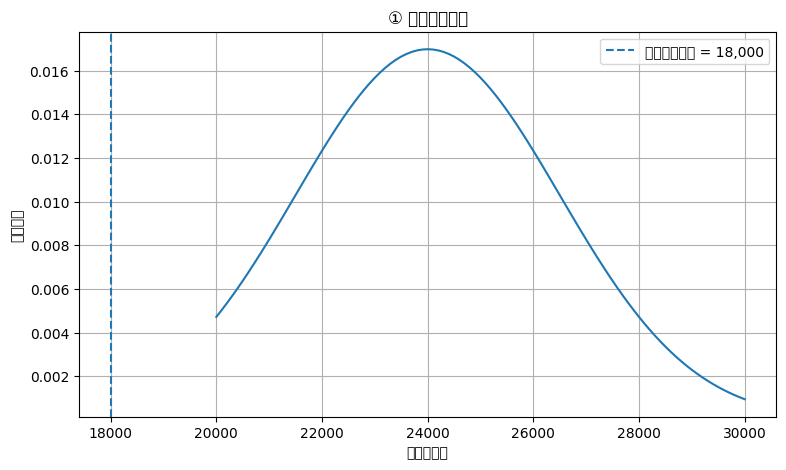

/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24453 (\N{CJK UNIFIED IDEOGRAPH-5F85}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12372

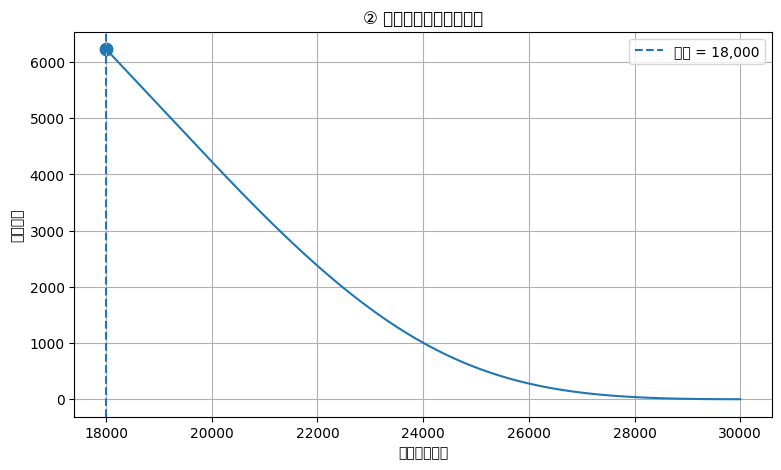

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 事後確率分布
# ============================================================
# 「商品の本当の価格」がどこにありそうかを表す分布
#
# ここでは例として、20,000～30,000円の範囲に
# 本当の価格があるとします。

prices = np.arange(20000, 30001, 100)

# 事後分布を作る
# 本当の価格は 24,000円あたりが一番ありそう、という設定
posterior = np.exp(-0.5 * ((prices - 24000) / 2500) ** 2)

# 確率の合計を1にする（正規化）
posterior = posterior / posterior.sum()


# ============================================================
# 2. 利益を計算する関数
# ============================================================
def gain(bid, true_price):
    """
    bid       : 自分の推定値
    true_price: 本当の価格

    今回は単純化して、

    ・高く見積もりすぎた → 利益 0
    ・低く見積もったほど → 利益が小さくなる

    というルールにします。
    """

    if bid > true_price:
        return 0

    return true_price - bid


# ============================================================
# 3. ある推定値を選んだときの「期待利益」
# ============================================================
def expected_gain(bid):
    """
    事後確率を使って期待利益を計算する
    """

    gains = np.array([
        gain(bid, price)
        for price in prices
    ])

    # 期待値
    return np.sum(posterior * gains)


# ============================================================
# 4. いろいろな推定値について期待利益を計算
# ============================================================
bids = np.arange(18000, 30001, 100)

expected_gains = np.array([
    expected_gain(bid)
    for bid in bids
])


# ============================================================
# 5. 期待利益が最大になる推定値
# ============================================================
best_index = np.argmax(expected_gains)

best_bid = bids[best_index]
best_gain = expected_gains[best_index]

print("期待利益が最大になる推定値:", best_bid)
print("そのときの期待利益:", best_gain)


# ============================================================
# 6. グラフ① 事後確率分布
# ============================================================
plt.figure(figsize=(9, 5))

plt.plot(prices, posterior)

plt.axvline(
    best_bid,
    linestyle="--",
    label=f"最適な推定値 = {best_bid:,}"
)

plt.xlabel("本当の価格")
plt.ylabel("事後確率")
plt.title("① 事後確率分布")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 7. グラフ② 推定値と期待利益
# ============================================================
plt.figure(figsize=(9, 5))

plt.plot(bids, expected_gains)

plt.axvline(
    best_bid,
    linestyle="--",
    label=f"最大 = {best_bid:,}"
)

plt.scatter(
    [best_bid],
    [best_gain],
    s=80
)

plt.xlabel("自分の推定値")
plt.ylabel("期待利益")
plt.title("② 推定値ごとの期待利益")
plt.legend()
plt.grid(True)

plt.show()

prior sum      = 0.9999999999999998
likelihood sum = 1.0
posterior sum  = 1.0000000000000002

最適な推定値 = $0
最大期待利益 = $31,552


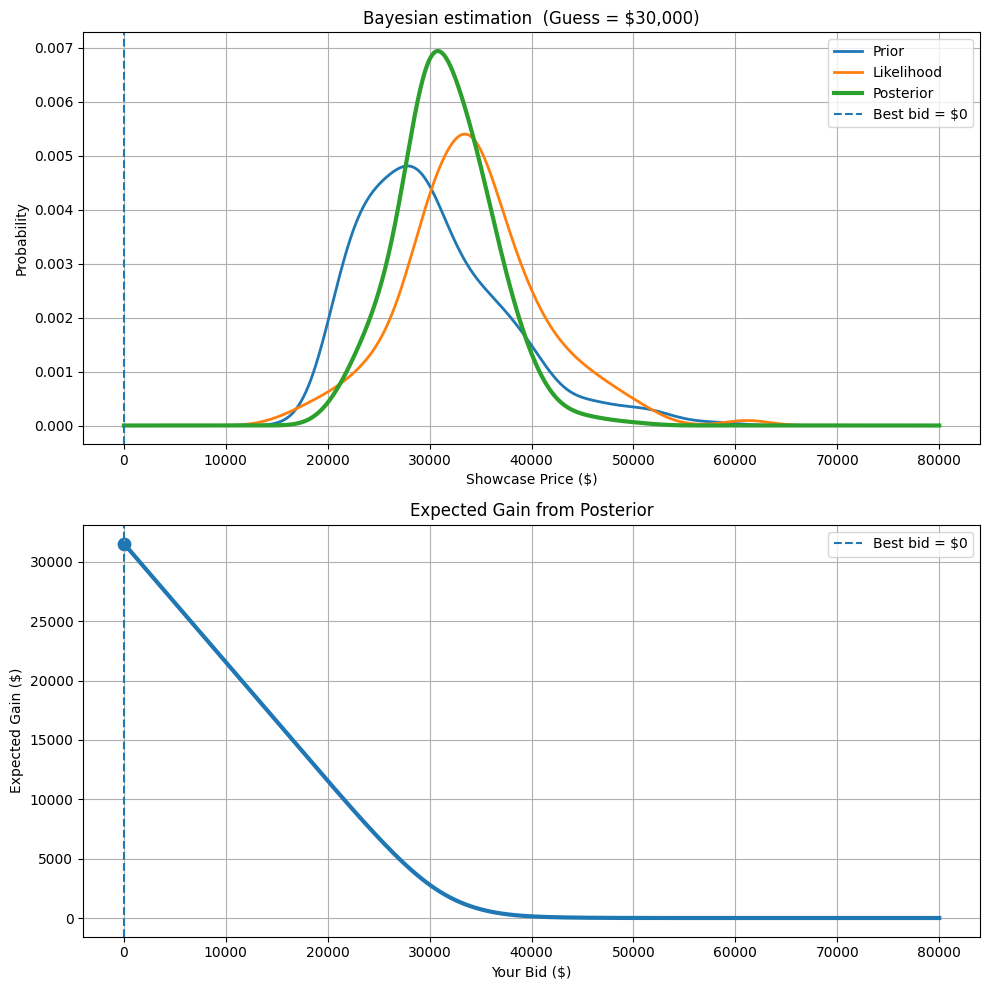

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# -----------------------------------
# 1. データ
# -----------------------------------

showcase = price_data3["Showcase1"].dropna().values
bid       = price_data3["Bid1"].dropna().values

error = bid - showcase


# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(showcase)
kde_error = gaussian_kde(error)


# -----------------------------------
# 3. 観測データ
# -----------------------------------

guess = 30000

# 仮説空間
xs = np.linspace(0, 80000, 1000)


# -----------------------------------
# 4. Prior
# -----------------------------------

prior = kde_price(xs)

# 離散確率化
prior = prior / prior.sum()


# -----------------------------------
# 5. Likelihood
# -----------------------------------

errors = guess - xs

likelihood = kde_error(errors)

# 比較しやすいように正規化
likelihood = likelihood / likelihood.sum()


# -----------------------------------
# 6. Posterior
# -----------------------------------

posterior = prior * likelihood

posterior = posterior / posterior.sum()


# -----------------------------------
# 7. 確認
# -----------------------------------

print("prior sum      =", prior.sum())
print("likelihood sum =", likelihood.sum())
print("posterior sum  =", posterior.sum())


# ==========================================================
# 8. 期待利益を計算する
# ==========================================================

def gain(bid, true_price):
    """
    bid       : 自分の推定値
    true_price: 本当の価格

    本当の価格を超えて入札したら利益 0。
    それ以外は「価格 - 入札額」を利益とする。
    """

    if bid > true_price:
        return 0

    return true_price - bid


def expected_gain(bid):
    """
    事後分布を使って、ある入札額の期待利益を計算する。
    """

    gains = np.array([
        gain(bid, price)
        for price in xs
    ])

    return np.sum(posterior * gains)


# -----------------------------------
# 9. いろいろな入札額について
#    期待利益を計算
# -----------------------------------

bids = np.linspace(0, 80000, 500)

expected_gains = np.array([
    expected_gain(bid)
    for bid in bids
])


# -----------------------------------
# 10. 最大期待利益の入札額
# -----------------------------------

best_index = np.argmax(expected_gains)

best_bid = bids[best_index]
best_gain = expected_gains[best_index]

print()
print("最適な推定値 =", f"${best_bid:,.0f}")
print("最大期待利益 =", f"${best_gain:,.0f}")


# ==========================================================
# 11. グラフ
# ==========================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 10)
)


# -----------------------------------
# 上：これまでの3つ
# -----------------------------------

axes[0].plot(
    xs, prior,
    label="Prior",
    linewidth=2
)

axes[0].plot(
    xs, likelihood,
    label="Likelihood",
    linewidth=2
)

axes[0].plot(
    xs, posterior,
    label="Posterior",
    linewidth=3
)

axes[0].axvline(
    best_bid,
    linestyle="--",
    label=f"Best bid = ${best_bid:,.0f}"
)

axes[0].set_xlabel("Showcase Price ($)")
axes[0].set_ylabel("Probability")
axes[0].set_title(
    f"Bayesian estimation  (Guess = ${guess:,.0f})"
)

axes[0].legend()
axes[0].grid()


# -----------------------------------
# 下：期待利益
# -----------------------------------

axes[1].plot(
    bids,
    expected_gains,
    linewidth=3
)

axes[1].axvline(
    best_bid,
    linestyle="--",
    label=f"Best bid = ${best_bid:,.0f}"
)

axes[1].scatter(
    best_bid,
    best_gain,
    s=80
)

axes[1].set_xlabel("Your Bid ($)")
axes[1].set_ylabel("Expected Gain ($)")
axes[1].set_title("Expected Gain from Posterior")

axes[1].legend()
axes[1].grid()


plt.tight_layout()
plt.show()

prior sum      = 0.9999999999999998
likelihood sum = 0.9999999999999999
posterior sum  = 1.0000000000000002

期待利益が最大になる推定値 = $26,293
事後分布の平均 = $26,217


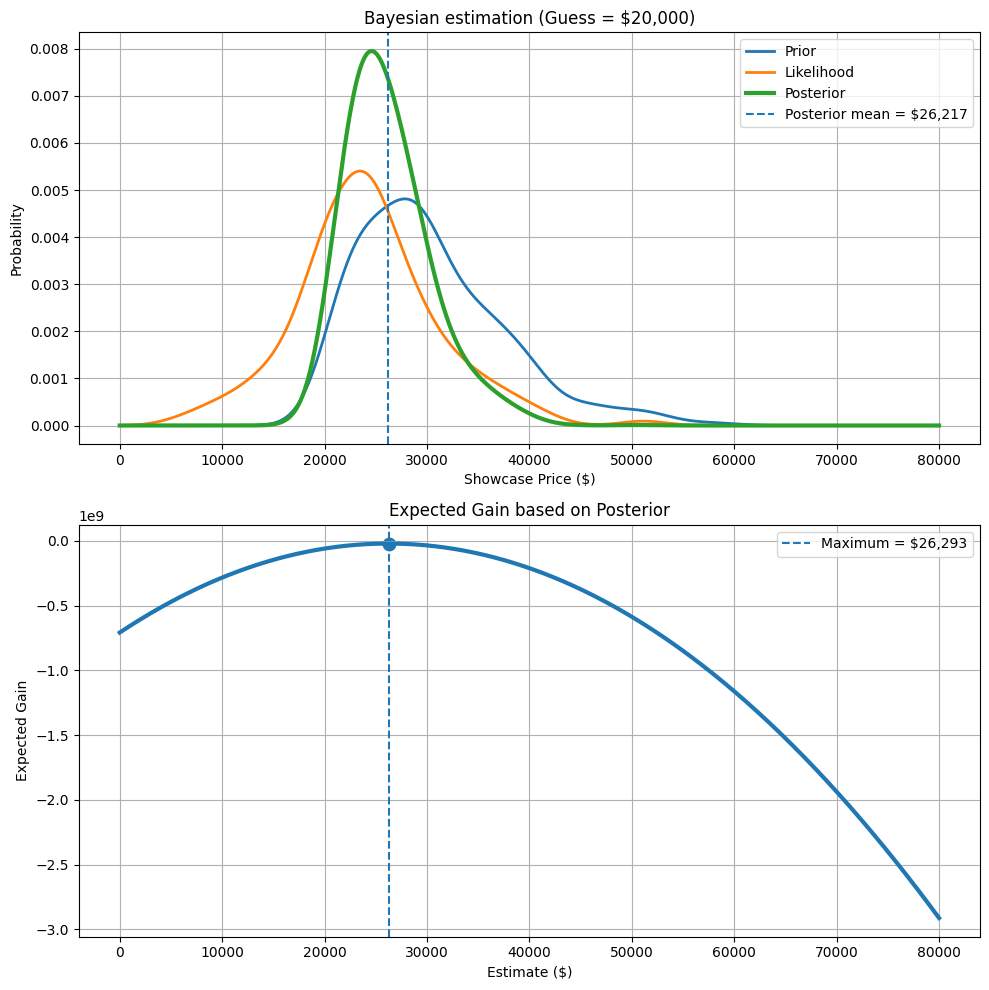

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# -----------------------------------
# 1. データ
# -----------------------------------

showcase = price_data3["Showcase1"].dropna().values
bid       = price_data3["Bid1"].dropna().values

error = bid - showcase


# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(showcase)
kde_error = gaussian_kde(error)


# -----------------------------------
# 3. 観測データ
# -----------------------------------

guess = 20000

xs = np.linspace(0, 80000, 1000)


# -----------------------------------
# 4. Prior
# -----------------------------------

prior = kde_price(xs)
prior = prior / prior.sum()


# -----------------------------------
# 5. Likelihood
# -----------------------------------

errors = guess - xs

likelihood = kde_error(errors)
likelihood = likelihood / likelihood.sum()


# -----------------------------------
# 6. Posterior
# -----------------------------------

posterior = prior * likelihood
posterior = posterior / posterior.sum()


# -----------------------------------
# 7. 確認
# -----------------------------------

print("prior sum      =", prior.sum())
print("likelihood sum =", likelihood.sum())
print("posterior sum  =", posterior.sum())


# ==========================================================
# 8. 事後分布から「期待利益」を計算
# ==========================================================

def gain(estimate, true_price):
    """
    推定値と真の価格のズレを「損失」と考える。

    ズレが小さいほど良い。
    そこで、二乗誤差のマイナスをGainとする。
    """

    return -(estimate - true_price) ** 2


def expected_gain(estimate):
    """
    事後分布を使って期待利益を計算する。
    """

    gains = gain(estimate, xs)

    return np.sum(posterior * gains)


# -----------------------------------
# 9. いろいろな推定値について
#    期待利益を計算
# -----------------------------------

estimates = np.linspace(0, 80000, 500)

expected_gains = np.array([
    expected_gain(estimate)
    for estimate in estimates
])


# -----------------------------------
# 10. 期待利益が最大になる推定値
# -----------------------------------

best_index = np.argmax(expected_gains)

best_estimate = estimates[best_index]
best_gain = expected_gains[best_index]


# -----------------------------------
# 11. 事後分布の平均も計算
# -----------------------------------

posterior_mean = np.sum(xs * posterior)


print()
print("期待利益が最大になる推定値 =",
      f"${best_estimate:,.0f}")

print("事後分布の平均 =",
      f"${posterior_mean:,.0f}")


# ==========================================================
# 12. グラフ
# ==========================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 10)
)


# -----------------------------------
# 上：Prior / Likelihood / Posterior
# -----------------------------------

axes[0].plot(
    xs, prior,
    label="Prior",
    linewidth=2
)

axes[0].plot(
    xs, likelihood,
    label="Likelihood",
    linewidth=2
)

axes[0].plot(
    xs, posterior,
    label="Posterior",
    linewidth=3
)

axes[0].axvline(
    posterior_mean,
    linestyle="--",
    label=f"Posterior mean = ${posterior_mean:,.0f}"
)

axes[0].set_xlabel("Showcase Price ($)")
axes[0].set_ylabel("Probability")

axes[0].set_title(
    f"Bayesian estimation (Guess = ${guess:,.0f})"
)

axes[0].legend()
axes[0].grid()


# -----------------------------------
# 下：期待利益
# -----------------------------------

axes[1].plot(
    estimates,
    expected_gains,
    linewidth=3
)

axes[1].axvline(
    best_estimate,
    linestyle="--",
    label=f"Maximum = ${best_estimate:,.0f}"
)

axes[1].scatter(
    best_estimate,
    best_gain,
    s=80
)

axes[1].set_xlabel("Estimate ($)")
axes[1].set_ylabel("Expected Gain")

axes[1].set_title(
    "Expected Gain based on Posterior"
)

axes[1].legend()
axes[1].grid()


plt.tight_layout()
plt.show()

In [59]:
import numpy as np


# -------------------------
# Playerクラス
# posteriorを持つだけ
# -------------------------
class Player:

    def __init__(self, posterior):
        self.posterior = posterior



# -------------------------
# Opponentクラス
# GainCalculatorが要求する
# 2つのメソッドだけ準備
# -------------------------
class Opponent:

    def ProbOverbid(self):
        # 仮の値
        return 0.1

    def ProbWorseThan(self, diff):
        # 仮の値
        # 本来は相手の分布から計算する
        return 0.5



# -------------------------
# ThinkBayesから貼ってくれた
# GainCalculator
# -------------------------
class GainCalculator:

    def __init__(self, player, opponent):
        self.player = player
        self.opponent = opponent


    def ExpectedGain(self, bid):

        suite = self.player.posterior

        total = 0

        for price, prob in sorted(suite.items()):

            gain = self.Gain(bid, price)

            total += prob * gain

        return total


    def Gain(self, bid, price):

        if bid > price:
            return 0

        diff = price - bid

        prob = self.ProbWin(diff)

        if diff <= 250:
            return 2 * price * prob
        else:
            return price * prob


    def ProbWin(self, diff):

        prob = (
            self.opponent.ProbOverbid()
            +
            self.opponent.ProbWorseThan(diff)
        )

        return prob



# =========================
# ここから実行部分
# =========================


# ① posteriorデータを作る
posterior = {
    10000: 0.2,
    20000: 0.5,
    30000: 0.3
}


# ② Playerインスタンスを作る
player = Player(posterior)


# ③ Opponentインスタンスを作る
opponent = Opponent()


# ④ GainCalculatorインスタンスを作る
calculator = GainCalculator(player, opponent)



# ⑤ ある入札額で期待利益を見る

bid = 20000

gain = calculator.ExpectedGain(bid)

print("入札額:", bid)
print("期待利益:", gain)

入札額: 20000
期待利益: 17400.0


In [60]:
df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


In [61]:
df3["Showcase 1"].to_numpy()

array([50969., 21901., 32815., 44432., 24273., 30554., 20963., 28941.,
       25851., 28800., 37703., 34774., 25268., 44044., 32516., 30827.,
       40374., 27698., 23590., 38625., 24026., 37449., 34268., 22281.,
       22890., 24226., 25448., 32525., 36799., 27380., 25903., 31769.,
       22853., 23202., 20721., 28451., 26154., 27019., 51959., 35811.,
       24885., 24648., 30707., 23744., 45078., 20773., 30892., 29971.,
       37423., 33593., 24866., 24628., 24827., 29248., 24818., 28762.,
       31838., 22268., 38892., 22599., 31705., 23299., 21394., 22589.,
       30573., 33009., 19612., 28550., 49937., 36915., 33400., 34516.,
       31516., 51108., 23981., 26383., 39801., 39201., 19563., 20418.,
       28465., 22356., 24150., 20425., 23926., 20860., 35526., 20912.,
       27426., 26393., 25329., 22434., 31933., 23986., 24729., 21747.,
       27273., 21681., 29324., 35874., 30397., 27310., 28414., 32535.,
       22886., 29842., 35954., 27883., 31268., 21563., 39642., 21862.,
      

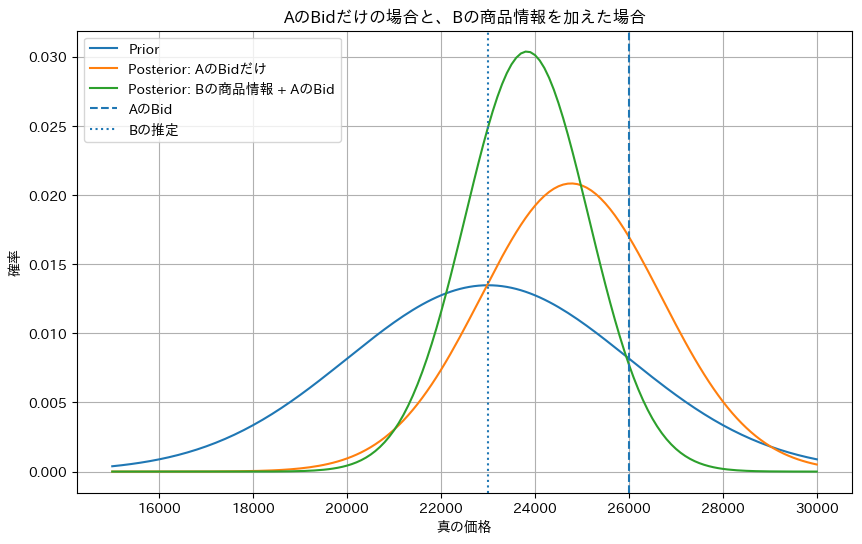

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


# ============================================
# 1. 真の価格の候補
# ============================================

price = np.arange(15000, 30001, 100)


# ============================================
# 2. Prior
#    過去の価格分布を単純な正規分布で作る
# ============================================

prior = np.exp(-0.5 * ((price - 23000) / 3000) ** 2)

# 正規化
prior = prior / np.sum(prior)


# ============================================
# 3. AのBid
# ============================================

A_bid = 26000

# Aの予想誤差の標準偏差
sigma_A = 2500

# AがこのBidをするLikelihood
likelihood_A = np.exp(
    -0.5 * ((A_bid - price) / sigma_A) ** 2
)


# ============================================
# 4. AのBidだけから作るPosterior
# ============================================

posterior_A = prior * likelihood_A

# 正規化
posterior_A = posterior_A / np.sum(posterior_A)


# ============================================
# 5. Bが商品を見て、自分では
#    23000くらいだと推定したとする
# ============================================

B_estimate = 23000

# Bの商品に対する推定誤差
sigma_B = 1800

likelihood_B = np.exp(
    -0.5 * ((B_estimate - price) / sigma_B) ** 2
)


# ============================================
# 6. Bの商品情報 + AのBid
#    からPosteriorを作る
# ============================================

posterior_AB = (
    prior
    * likelihood_A
    * likelihood_B
)

# 正規化
posterior_AB = posterior_AB / np.sum(posterior_AB)


# ============================================
# 7. グラフ
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    price,
    prior,
    label="Prior"
)

plt.plot(
    price,
    posterior_A,
    label="Posterior: AのBidだけ"
)

plt.plot(
    price,
    posterior_AB,
    label="Posterior: Bの商品情報 + AのBid"
)

plt.axvline(
    A_bid,
    linestyle="--",
    label="AのBid"
)

plt.axvline(
    B_estimate,
    linestyle=":",
    label="Bの推定"
)

plt.xlabel("真の価格")
plt.ylabel("確率")
plt.title("AのBidだけの場合と、Bの商品情報を加えた場合")
plt.legend()
plt.grid()
plt.show()

prior sum        = 1.0000000000000002
likelihood_A sum = 1.0000000000000002
likelihood_B sum = 1.0
posterior_A sum  = 1.0
posterior_AB sum = 1.0


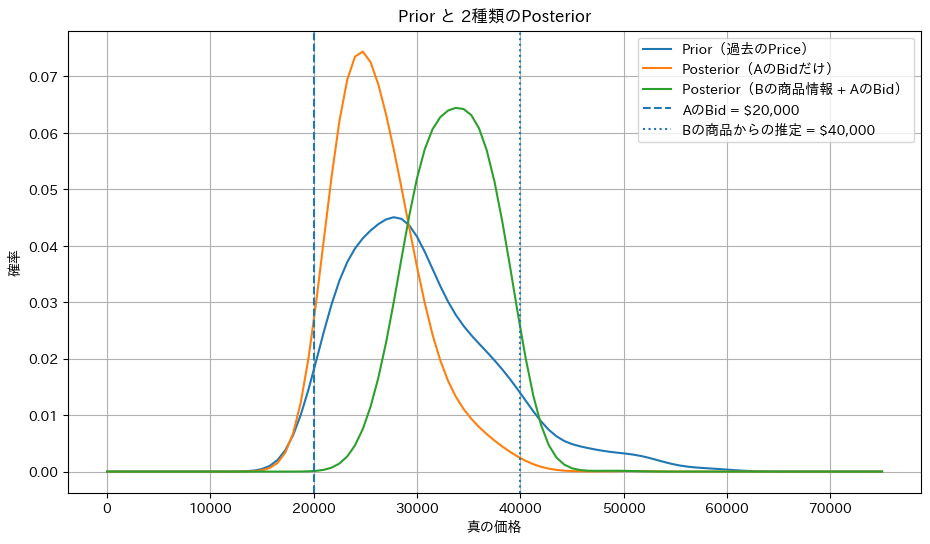

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# -----------------------------------
# 1. データ
# -----------------------------------

showcase = price_data3["Showcase1"].dropna().values
bid      = price_data3["Bid1"].dropna().values

error = bid - showcase


# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(showcase)
kde_error = gaussian_kde(error)


# -----------------------------------
# 3. 観測データ
# -----------------------------------

# AのBid
A_bid = 20000

# Bが商品を見て、自分では
# このくらいだと推定したとする
B_estimate = 40000

# 仮説空間
xs = np.linspace(0, 75000, 101)


# -----------------------------------
# 4. Prior
# -----------------------------------

prior = kde_price(xs)

# 離散確率化
prior = prior / prior.sum()


# -----------------------------------
# 5. AのBidによるLikelihood
# -----------------------------------

errors_A = A_bid - xs

likelihood_A = kde_error(errors_A)

likelihood_A = likelihood_A / likelihood_A.sum()


# -----------------------------------
# 6. AのBidだけから作るPosterior
# -----------------------------------

posterior_A = prior * likelihood_A

posterior_A = posterior_A / posterior_A.sum()


# -----------------------------------
# 7. Bの商品情報
# -----------------------------------

# Bの商品に対する推定誤差の幅
sigma_B = 5000

likelihood_B = np.exp(
    -0.5 * ((B_estimate - xs) / sigma_B) ** 2
)

likelihood_B = likelihood_B / likelihood_B.sum()


# -----------------------------------
# 8. Bの商品情報 + AのBid
#    から作るPosterior
# -----------------------------------

posterior_AB = (
    prior
    * likelihood_A
    * likelihood_B
)

posterior_AB = posterior_AB / posterior_AB.sum()


# -----------------------------------
# 9. 確認
# -----------------------------------

print("prior sum        =", prior.sum())
print("likelihood_A sum =", likelihood_A.sum())
print("likelihood_B sum =", likelihood_B.sum())
print("posterior_A sum  =", posterior_A.sum())
print("posterior_AB sum =", posterior_AB.sum())


# -----------------------------------
# 10. グラフ
# -----------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    xs,
    prior,
    label="Prior（過去のPrice）"
)

plt.plot(
    xs,
    posterior_A,
    label="Posterior（AのBidだけ）"
)

plt.plot(
    xs,
    posterior_AB,
    label="Posterior（Bの商品情報 + AのBid）"
)

plt.axvline(
    A_bid,
    linestyle="--",
    label=f"AのBid = ${A_bid:,}"
)

plt.axvline(
    B_estimate,
    linestyle=":",
    label=f"Bの商品からの推定 = ${B_estimate:,}"
)

plt.xlabel("真の価格")
plt.ylabel("確率")
plt.title("Prior と 2種類のPosterior")
plt.legend()
plt.grid()

plt.show()

In [64]:
# -------------------------
# 動作確認用のダミーデータ
# -------------------------
'''
player = "Player A"
opponent = "Player B"


# GainCalculator のインスタンスを作る
calculator = GainCalculator(player, opponent)


# 中に保存されたものを確認する
print("calculator =", calculator)
print("calculator.player =", calculator.player)
print("calculator.opponent =", calculator.opponent)

'''

'\nplayer = "Player A"\nopponent = "Player B"\n\n\n# GainCalculator のインスタンスを作る\ncalculator = GainCalculator(player, opponent)\n\n\n# 中に保存されたものを確認する\nprint("calculator =", calculator)\nprint("calculator.player =", calculator.player)\nprint("calculator.opponent =", calculator.opponent)\n\n'

In [65]:
import numpy as np

class GainCalculator(object):

    def __init__(self, player, opponent):
        self.player = player
        self.opponent = opponent

    def ExpectedGain(self, bid):
        suite = self.player.posterior

        total = 0

        for price, prob in sorted(suite.items()):

            gain = self.Gain(bid, price)

            total += prob * gain

        return total

    def ExpectedGains(self, low=0, high=75000, n=101):
        """Computes expected gains for a range of bids.

        low: low bid
        high: high bid
        n: number of bids to evaluate

        returns: tuple (sequence of bids, sequence of gains)
        """

        bids = np.linspace(low, high, n)
        gains = [self.ExpectedGain(bid) for bid in bids]

        return bids, gains
    

    # 今回は動作確認用の仮の Gain
    def Gain(self, bid, price):
        if bid > price:
            return 0
        
        diff = price - bid
        prob = self.ProbWin(diff)

        if diff <= 250:
            return 3 * price * prob
        else:
            return price * prob

    def ProbWin(self, diff):
        prob = (
            self.opponent.ProbOverbid()
            +
            self.opponent.ProbWorseThan(diff)
        )
        return prob


class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = thinkbayes.EstimatedPdf(prices)
        self.cdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)


    def ErrorDensity(self, error):
        """Density of the given error in the distribution of errror.
        error: how much the bid is under the actual price
        """
        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Returns a new Pmf of prices.
        A discrete version of the estimated Pdf.
        """
        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Returns a reference to th Cdf of differences (underness)."""

        return self.cdf_diff

    def ProbOverbid(self):
        """Returns the probability this player overbids."""

        return self.cdf_diff.Prob(-1)

    def ProbWorseThan(self, diff):
        """Probability this player's diff is greater than the given diff.
        diff: how much the oppenent is off by (always positive)
        """

        return 1 - self.cdf_diff.Prob(diff)

    def MakeBeliets(self, guess):
        """Makes a posterior distributuion based on estimated price.
        Sets attributes prior and posterior.
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name="prior")
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)

    def OptimalBid(self, guess, opponent):
        """Computes the bid that maximizes expected return.
        guess: what the player thinks the showcase is worth
        opponent: Player
        returns: (optimal bid, expected gain)
        """

        self.MakeBeliets(guess)
        calc = GainCalculator(self, opponent)
        bids, gains = calc.ExpectedGains()
        gain, bid = max(zip(gains, bids))
        return bid, gain
    
print(type(calculator.player))
print(calculator.player)


<class '__main__.Player'>


In [66]:
calculator


In [67]:
#player = "Player A"
calculator = GainCalculator(player, opponent)

calculator.player


In [68]:
print(calculator.player.posterior)

bid = 20000

expected_gain = calculator.ExpectedGain(bid)
expected_gain

{10000: 0.2, 20000: 0.5, 30000: 0.3}


23400.0

In [69]:
bids, gains = calculator.ExpectedGains(low=0, high=75000, n=101)
print("bids =", bids)
print("gains =", gains)

bids = [    0.   750.  1500.  2250.  3000.  3750.  4500.  5250.  6000.  6750.
  7500.  8250.  9000.  9750. 10500. 11250. 12000. 12750. 13500. 14250.
 15000. 15750. 16500. 17250. 18000. 18750. 19500. 20250. 21000. 21750.
 22500. 23250. 24000. 24750. 25500. 26250. 27000. 27750. 28500. 29250.
 30000. 30750. 31500. 32250. 33000. 33750. 34500. 35250. 36000. 36750.
 37500. 38250. 39000. 39750. 40500. 41250. 42000. 42750. 43500. 44250.
 45000. 45750. 46500. 47250. 48000. 48750. 49500. 50250. 51000. 51750.
 52500. 53250. 54000. 54750. 55500. 56250. 57000. 57750. 58500. 59250.
 60000. 60750. 61500. 62250. 63000. 63750. 64500. 65250. 66000. 66750.
 67500. 68250. 69000. 69750. 70500. 71250. 72000. 72750. 73500. 74250.
 75000.]
gains = [12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 15000.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 5400.0, 5400.0, 5400.0

In [70]:
print("calculator :", type(calculator))
print("player     :", type(calculator.player))
print("player obj :", calculator.player)
print("calculator :", calculator)

calculator : <class '__main__.GainCalculator'>
player     : <class '__main__.Player'>
player obj : <__main__.Player object at 0x1399eab10>
calculator : <__main__.GainCalculator object at 0x139bf21e0>


In [71]:
print("Playerの中身 =", calculator.player.__dict__)
print("posterior =", calculator.player.posterior)
print("posteriorの型 =", type(calculator.player.posterior))

Playerの中身 = {'posterior': {10000: 0.2, 20000: 0.5, 30000: 0.3}}
posterior = {10000: 0.2, 20000: 0.5, 30000: 0.3}
posteriorの型 = <class 'dict'>


In [72]:
print(calculator.ExpectedGain(20000))

23400.0


In [73]:
bids = np.linspace(0, 75000, 101)

print(bids[:5])
print(bids[-5:])
print(len(bids))

[   0.  750. 1500. 2250. 3000.]
[72000. 72750. 73500. 74250. 75000.]
101


In [74]:
gains = [calculator.ExpectedGain(bid) for bid in bids]

print(gains[:5])
print(gains[-5:])
print(len(gains))

[12600.0, 12600.0, 12600.0, 12600.0, 12600.0]
[0.0, 0.0, 0.0, 0.0, 0.0]
101


In [75]:
bids, gains = calculator.ExpectedGains(low=0, high=75000, n=101)

print("bids =", bids)
print("gains =", gains)

bids = [    0.   750.  1500.  2250.  3000.  3750.  4500.  5250.  6000.  6750.
  7500.  8250.  9000.  9750. 10500. 11250. 12000. 12750. 13500. 14250.
 15000. 15750. 16500. 17250. 18000. 18750. 19500. 20250. 21000. 21750.
 22500. 23250. 24000. 24750. 25500. 26250. 27000. 27750. 28500. 29250.
 30000. 30750. 31500. 32250. 33000. 33750. 34500. 35250. 36000. 36750.
 37500. 38250. 39000. 39750. 40500. 41250. 42000. 42750. 43500. 44250.
 45000. 45750. 46500. 47250. 48000. 48750. 49500. 50250. 51000. 51750.
 52500. 53250. 54000. 54750. 55500. 56250. 57000. 57750. 58500. 59250.
 60000. 60750. 61500. 62250. 63000. 63750. 64500. 65250. 66000. 66750.
 67500. 68250. 69000. 69750. 70500. 71250. 72000. 72750. 73500. 74250.
 75000.]
gains = [12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 12600.0, 15000.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 11400.0, 5400.0, 5400.0, 5400.0

In [76]:
print(type(player))
print(player.__dict__.keys())

<class '__main__.Player'>
dict_keys(['posterior'])


In [77]:
print(player.posterior)

{10000: 0.2, 20000: 0.5, 30000: 0.3}


In [78]:
%whos

Variable              Type              Data/Info
-------------------------------------------------
A_bid                 int               20000
B_estimate            int               40000
Counter               type              <class 'collections.Counter'>
EstimatedPdf          type              <class '__main__.EstimatedPdf'>
FuncAnimation         type              <class 'matplotlib.animation.FuncAnimation'>
GainCalculator        type              <class '__main__.GainCalculator'>
GaussianPdf           type              <class '__main__.GaussianPdf'>
MakeCdfFromList       function          <function MakeCdfFromList at 0x139371440>
MakeHistFromList      function          <function MakeHistFromList at 0x13931e660>
Opponent              type              <class '__main__.Opponent'>
Pdf                   type              <class '__main__.Pdf'>
Player                type              <class '__main__.Player'>
Pmf                   type              <class 'thinkbayes.Pmf'>
Price    

In [79]:
print("y3 =", y3)
print("y4 =", y4)

y3 = <thinkbayes.Pmf object at 0x13932daf0>
y4 = <thinkbayes.Pmf object at 0x13932d550>


In [80]:
for name, obj in list(globals().items()):
    if isinstance(obj, Player):
        print(name, obj.__dict__.keys())